In [6]:

# =============================================================================
# Cell 1: Setup and Imports
# =============================================================================
%load_ext autoreload
%autoreload 2
%matplotlib inline

from pathlib import Path
import sqlite3
import sys
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import Planck18 as cosmo

# Add your repo to path if not installed as package
repo_root = Path("/Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric")
sys.path.insert(0, str(repo_root / "py_files"))

# Import from refactored package
from slsn_metrics import (
    # Core model
    _compute_grid_slice,
    LC, 
    CatalogInputs,
    
    # Export & cenwave
    per_filter_cenwave,
    attach_cenwave_to_perevent_csv,
    audit_cenwave_mode,
    audit_cenwave_variability,
    
    # Population
    generate_SLSN_PopSlicer,
    sample_rate_from_volume, 
    inject_uniform_healpix,
    
    # Metrics
    SLSN_Detect_Metric,
    SLSN_CharacterizeMetric,
    SLSN_SpecTriggerMetric,

    #Runners
    get_distance_bounds,
    build_filenames,
    run_slsn_detect,
    _build_detection_dataframe,
    _make_all_detection_plots,
    run_slsn_multi_metrics,
    
    # Diagnostics
    _get_available_bands,
    plot_population_lc_at_obs, 
    plot_population_lc_multi_at_obs,
    validate_template_quality,
    diagnose_abs_from_templates,
    plot_residuals,
    plot_event_obs,
    plot_event_model,
    plot_event_obs_vs_model,
    list_event_bands,
    list_template_bands,
    characterize_template_coverage,
    compute_slsn_properties,
    assess_literature_coverage,
    find_missing_archetypes,
    
    # Utilities
    template_index_for_event,
    list_t0_meta,
)

# Import shared utilities (assuming this is still a separate file)
#import shared_utils

print("Imports successful")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Imports successful


In [8]:
%reload_ext autoreload



In [10]:
# =============================================================================
# Cell 2: Configuration
# =============================================================================

# Paths
supernovae_dir = Path("/Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/SLSNe/slsne/ref_data/supernovae")
out_perevent = Path("/Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/per_event_files")
allparams_csv = Path("/Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/all_events/allparameter.csv")
base_dir = Path("/Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric")
db_dir = Path("/Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub")

# Science case label
science_case = "SLSNe"

# =============================================================================
# CONTROL FLAGS - Toggle regeneration behavior
# =============================================================================
GENERATE_NEW_TEMPLATES = True  # Set True to rebuild templates from scratch
GENERATE_NEW_POPULATION = True  # Set True to regenerate population
FORCE_REBUILD_MAG_GRID = True   # Set True to rebuild magnitude grid

use_kcorrect = False
ignore_triples = True
use_extinction = True
gal_lat_cut = 15 # 15 for extra galactic

ignore_triples=True,
save_csv=True,
make_plots=True, #detection
clean_temp=True,
verbose=True
make_debug_plots=True #population 

# =============================================================================
# Survey Parameters (SINGLE SOURCE OF TRUTH)
# =============================================================================
mjd0 = 60980.5         # Survey start MJD (from baseline_v4.3.1)
t_start = 1             # Event window start (days from mjd0)
t_end = 3652            # Event window end (days from mjd0) = 10 years
survey_duration = t_end - t_start

# =============================================================================
# Science Parameters
# =============================================================================
# Redshift range
z_min = 0.001
z_max = 0.3

# Mpc Range
d_min = None
d_max= None

# Rate density (volumetric)
rate_density = 3e-8  # Mpc^-3 yr^-1

# Template building
n_time_steps = 220
tpad_pre_peak = 5.0
tpad_post_peak = 160.0

# Random seed (for reproducibility)
seed = 42

# Cadence to use
cadence = 'baseline_v4.3.1_10yrs'

testname = f"z_{z_min}-{z_max}_rate_{rate_density}"
testname_metric = "detect"

templates_file, pop_file, df_file, storage_dir, summary_filename = build_filenames(
    rate_density=rate_density,
    z_min=z_min,
    z_max=z_max,
    d_min=None,
    d_max=None,
    science_case=science_case,
    testname=testname,
    testname_metric_only=testname_metric,
    ignore_triples=True,
    use_extinction=True,
    use_kcorrect=False,
    base_dir=str(base_dir / "output/Rubin_tests")
)

# Convert to Path objects
templates_file = Path(templates_file)
pop_file = Path(pop_file)
storage_dir = Path(storage_dir)
grid_file = templates_file.parent / f"{templates_file.stem}_mag_grid.pkl"

# Create directories
storage_dir.mkdir(parents=True, exist_ok=True)

# =============================================================================
# Summary
# =============================================================================
print("="*70)
print("SLSN Metrics Configuration")
print("="*70)

print(f"\n Control Flags:")
print(f"  GENERATE_NEW_TEMPLATES:  {GENERATE_NEW_TEMPLATES}")
print(f"  GENERATE_NEW_POPULATION: {GENERATE_NEW_POPULATION}")
print(f"  FORCE_REBUILD_MAG_GRID:  {FORCE_REBUILD_MAG_GRID}")

print(f"\n Survey Parameters:")
print(f"  Survey start (mjd0):     {mjd0}")
print(f"  Event window:            t={t_start} to {t_end} days ({survey_duration/365.25:.1f} years)")
print(f"  Absolute MJD range:      {mjd0 + t_start:.1f} to {mjd0 + t_end:.1f}")

print(f"\n Science Parameters:")
print(f"  Redshift range:          {z_min} - {z_max}")
print(f"  Rate density:            {rate_density:.1e} Mpc^-3 yr^-1")
print(f"  Seed:                    {seed}")
print(f"  Cadence:                 {cadence}")

print(f"\n File Paths:")
print(f"  Templates:               {templates_file.name}")
print(f"  Population:              {pop_file.name}")
print(f"  Mag grid:                {grid_file.name}")
print(f"  Output dir:              {storage_dir}")

print(f"\n Configuration complete")




SLSNe_den_3e-08_d_None-None_Mpc_z_0.001-0.3_ext_True_kcor_False_z_0.001-0.3_rate_3e-08
SLSN Metrics Configuration

 Control Flags:
  GENERATE_NEW_TEMPLATES:  True
  GENERATE_NEW_POPULATION: True
  FORCE_REBUILD_MAG_GRID:  True

 Survey Parameters:
  Survey start (mjd0):     60980.5
  Event window:            t=1 to 3652 days (10.0 years)
  Absolute MJD range:      60981.5 to 64632.5

 Science Parameters:
  Redshift range:          0.001 - 0.3
  Rate density:            3.0e-08 Mpc^-3 yr^-1
  Seed:                    42
  Cadence:                 baseline_v4.3.1_10yrs

 File Paths:
  Templates:               SLSNe_den_3e-08_d_None-None_Mpc_z_0.001-0.3_ext_True_kcor_False_z_0.001-0.3_rate_3e-08_templates.pkl
  Population:              SLSNe_den_3e-08_d_None-None_Mpc_z_0.001-0.3_ext_True_kcor_False_z_0.001-0.3_rate_3e-08_population.pkl
  Mag grid:                SLSNe_den_3e-08_d_None-None_Mpc_z_0.001-0.3_ext_True_kcor_False_z_0.001-0.3_rate_3e-08_templates_mag_grid.pkl
  Output dir:     

In [12]:
if templates_file.exists():
   print("ERROR: File still exists!")
else:
   print(" File deleted")

ERROR: File still exists!


In [14]:
# =============================================================================
# Cell 3: Attach Cenwave to Per-Event Files
# =============================================================================


# Check if cenwave already attached
sample_csv = list(out_perevent.glob("*_cenwave.csv"))

if sample_csv:
    print(f" Central wavelength data already exists")
    print(f"   Found {len(sample_csv)} files in {out_perevent}")

else:
    for csv in sorted(out_perevent.glob("*.csv")):
        # Skip summary/derived files
        if csv.name.startswith("_") or csv.name.endswith("_cenwave.csv"):
            continue
        
        name = csv.stem
        
        # Calculate cenwave map
        cen_map = per_filter_cenwave(
            supernovae_dir, name, rel_bin=0.02, verbose=True
        )
        
        # Audit for outliers
        diag_mode = audit_cenwave_mode(
            supernovae_dir, name, rel_bin=0.02, outlier_frac_thresh=0.25
        )
        
        summary, var_df = audit_cenwave_variability(supernovae_dir, name)
        
        # Flag issues
        if not var_df.empty and (var_df["flag_scatter"].any() or var_df["flag_trend"].any()):
            print(f"[audit] {name}: potential Cenwave variability:")
            print(var_df.loc[var_df["flag_scatter"] | var_df["flag_trend"],
                             ["filter", "rel_scatter", "slope_A_per_day", "r2"]])
        
        if not diag_mode.empty and diag_mode["flag_outliers"].any():
            print(f"[audit] {name}: filters with outliers:")
            print(diag_mode.loc[diag_mode["flag_outliers"],
                                ["source", "filter", "n_rows", "mode_center_A", "frac_outside"]])
        
        # Attach cenwave
        attach_cenwave_to_perevent_csv(csv, cen_map)
    
    print("Cenwave attached to all events")



 Central wavelength data already exists
   Found 265 files in /Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/per_event_files


In [ ]:
# =============================================================================
# Cell 4: Build Templates (with Toggle)
# =============================================================================

if GENERATE_NEW_TEMPLATES or not templates_file.exists():
    print(f"\n[BUILD] Creating templates...")
    if GENERATE_NEW_TEMPLATES and templates_file.exists():
        print(f"    Overwriting existing templates (GENERATE_NEW_TEMPLATES=True)")
    
    templates_file.parent.mkdir(parents=True, exist_ok=True)
    
    inputs = CatalogInputs(
        photometry_dir=out_perevent,
        params_table=pd.read_csv(allparams_csv),
        name_col="name",
        z_col="redshift_med",
        peak_mjd_col="Peak_MJD_med"
    )
    
    print(f"  Processing {len(inputs.params_table)} events...")
    
    templates = LC.from_catalog(
        inputs,
        filename_pattern="{name}_cenwave.csv",
        save_to=templates_file,
        n_time=n_time_steps,
        tpad_pre_days=tpad_pre_peak,
        tpad_post_days=tpad_post_peak,
        min_points_for_fit=6,
    )
    
    print(f" Built {len(templates.data)} templates")
    print(f"   Saved to: {templates_file}")
else:
    print(f"\n[LOAD] Loading existing templates...")
    templates = LC(load_from=templates_file)
    print(f" Loaded {len(templates.data)} templates")
    print(f"   From: {templates_file}")
    print(f"   (Set GENERATE_NEW_TEMPLATES=True in Cell 2 to rebuild)")

print(f"\n  Template names: {templates.names[:5]}...")

# Quality check
issues = validate_template_quality(templates_file, min_bands=3, min_phase_span=20)
if not issues.empty:
    print(f"\n    Templates with quality issues:")
    print(issues)
else:
    print(f"   All templates pass quality checks")


print(f"\n File Paths:")
print(f"  Templates:               {templates_file.name}")
print(f"  Population:              {pop_file.name}")
print(f"  Mag grid:                {grid_file.name}")
print(f"  Output dir:              {storage_dir}")

print(f"\n Configuration complete")



In [16]:
templates = LC(load_from="/Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe/SLSNe_den_3e-08_d_None-None_Mpc_z_0.001-0.3_ext_True_kcor_False_z_0.001-0.3_rate_3e-08_templates.pkl")


# Check what bands templates have
template_0 = templates.data[0]
print(f"Template 0 bands: {[k for k in template_0.keys() if isinstance(template_0[k], dict)]}")


Template 0 bands: ['B', 'R', 'V']


In [18]:
# After loading templates
print("\n=== ACTUAL SED GRID CHECK ===")
sed = templates.sed_grid[0]  # First template
print(f"Wavelengths stored: {sed['lam_rest_A'].min():.1f} - {sed['lam_rest_A'].max():.1f} Å")
print(f"Expected: 3000-9000 Å")

if sed['lam_rest_A'].min() > 1500 or sed['lam_rest_A'].min() < 2000:
    print("⚠️ WRONG! Templates have bad wavelengths!")
    print("The templates object in memory is OLD")


=== ACTUAL SED GRID CHECK ===
Wavelengths stored: 4082.6 - 6538.9 Å
Expected: 3000-9000 Å
⚠️ WRONG! Templates have bad wavelengths!
The templates object in memory is OLD


In [ ]:
# =============================================================================
# Cell 5: Build Magnitude Grid (with Toggle)
# =============================================================================
if FORCE_REBUILD_MAG_GRID or not grid_file.exists():
    print(f"\n[BUILD] Building magnitude grid...")
    if FORCE_REBUILD_MAG_GRID and grid_file.exists():
        print(f"    Overwriting existing grid (FORCE_REBUILD_MAG_GRID=True)")
    
    print(f"  Processing {len(templates.data)} templates")
    print(f"  This will take ~5-15 minutes")
    print(f"  Checkpointing every 50 templates for safety")
    
    templates.build_magnitude_grid(
        # z_grid and phase_grid will auto-detect from templates!
        # You can still override if needed:
        # z_grid=np.linspace(0.02, 2.0, 50),
        # phase_grid=np.geomspace(0.1, 160, 210),
        filters='ugrizy',
        save_to=grid_file,
        checkpoint_every=50
    )
    
    print(f" Magnitude grid saved to {grid_file}")
else:
    print(f"\n[LOAD] Loading magnitude grid...")
    templates.load_magnitude_grid(grid_file)
    print(f" Magnitude grid loaded from {grid_file}")
    print(f"   Enables 100x+ speedup in metric evaluation")
    print(f"   (Set FORCE_REBUILD_MAG_GRID=True in Cell 2 to rebuild)")

In [20]:
# Add this diagnostic cell after loading the grid
print("\n=== LOADED GRID VERIFICATION ===")
print(f"Grid file path: {grid_file}")
print(f"File exists: {grid_file.exists()}")

if hasattr(templates, 'mag_grid_axes'):
    phase_grid = templates.mag_grid_axes['phase']
    z_grid = templates.mag_grid_axes['z']
    
    print(f"\nLoaded grid phase range: [{phase_grid.min():.2f}, {phase_grid.max():.2f}] days")
    print(f"Loaded grid z range: [{z_grid.min():.3f}, {z_grid.max():.3f}]")
    print(f"Loaded grid phase points: {len(phase_grid)}")
    
    # Check if it has negative phases
    if phase_grid.min() >= 0:
        print("\n  WARNING: Grid has NO NEGATIVE PHASES!")
        print("   This is an OLD grid built before auto-detect.")
        print("   You must delete it and rebuild.")
else:
    print("ERROR: No mag_grid_axes found!")


=== LOADED GRID VERIFICATION ===
Grid file path: /Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe/SLSNe_den_3e-08_d_None-None_Mpc_z_0.001-0.3_ext_True_kcor_False_z_0.001-0.3_rate_3e-08_templates_mag_grid.pkl
File exists: True
ERROR: No mag_grid_axes found!


In [22]:
# Check what's actually stored in the grid
print("\n=== GRID CONTENTS CHECK ===")
tpl_idx = 246
z_test = 0.32
phase_test = 50.0
filt_test = 'r'

if hasattr(templates, 'mag_grid') and filt_test in templates.mag_grid:
    z_grid = templates.mag_grid_axes['z']
    phase_grid = templates.mag_grid_axes['phase']
    
    # Find nearest grid points
    z_idx = np.argmin(np.abs(z_grid - z_test))
    phase_idx = np.argmin(np.abs(phase_grid - phase_test))
    
    grid_value = templates.mag_grid[filt_test][tpl_idx, z_idx, phase_idx]
    
    print(f"Template {tpl_idx}, filter {filt_test}")
    print(f"  Grid value at z={z_test}, phase={phase_test}: {grid_value}")
    print(f"  Nearest grid point: z={z_grid[z_idx]:.3f}, phase={phase_grid[phase_idx]:.1f}")


=== GRID CONTENTS CHECK ===


In [25]:
# Run to see what is in the checkpoint

# Quick test?
# templates.build_magnitude_grid(..., checkpoint_every=20)
# ls -lh /path/to/slsn_templates_mag_grid.checkpoint.pkl

checkpoint_file = grid_file.with_suffix('.checkpoint.pkl')

if checkpoint_file.exists():
    with open(checkpoint_file, 'rb') as f:
        cp = pickle.load(f)
    
    print(f"Checkpoint status:")
    print(f"  Completed: {cp['last_completed'] + 1}/{cp['n_templates']} templates")
    print(f"  Filters: {cp['filters']}")
    print(f"  Progress: {100 * (cp['last_completed'] + 1) / cp['n_templates']:.1f}%")
else:
    print("No checkpoint file found")

No checkpoint file found


In [27]:
# =============================================================================
# Optional Test: Check Metadata Structure
# =============================================================================

import pickle

# Load and inspect
with open(templates_file, 'rb') as f:
    obj = pickle.load(f)

meta = obj.get('meta', {})
print(f"Meta type: {type(meta)}")
print(f"Meta keys: {list(meta.keys()) if isinstance(meta, dict) else 'N/A'}")

if isinstance(meta, dict):
    for k, v in meta.items():
        if isinstance(v, (list, np.ndarray)):
            print(f"  {k}: {type(v).__name__} with {len(v)} entries")
        else:
            print(f"  {k}: {type(v).__name__}")

# Test the fixed function
from slsn_metrics import list_t0_meta
df = list_t0_meta(templates_file)

print(f"\n Successfully loaded metadata:")
print(f"  {len(df)} rows")
print(f"  Columns: {df.columns.tolist()}")
print(f"\nFirst few entries:")
print(df.head())



Meta type: <class 'dict'>
Meta keys: ['z', 'dm', 't0_cat', 't0_data', 'template_hash', 'grid_meta']
  z: list with 261 entries
  dm: list with 261 entries
  t0_cat: list with 261 entries
  t0_data: list with 261 entries
  template_hash: str
  grid_meta: dict

 Successfully loaded metadata:
  261 rows
  Columns: ['name', 'z', 'dm', 't0_cat', 't0_data', 't0_used', 'source']

First few entries:
     name        z         dm       t0_cat       t0_data       t0_used  \
0   1991D  0.04179  36.405254  48279.70968  48279.709680  48279.709680   
1  1999as  0.12700  38.944338  51236.05072  51236.050720  51236.050720   
2  2002gh  0.36530  41.520194  52562.80000  52562.800000  52562.800000   
3  2005ap  0.28320  40.880285  53440.40000  53452.056358  53452.056358   
4  2006oz  0.37600  41.593581  54085.34895  54085.348950  54085.348950   

    source  
0  catalog  
1  catalog  
2  catalog  
3  catalog  
4  catalog  


In [29]:
# =============================================================================
# Cell 5.5: Verify Templates Structure
# =============================================================================

print("Checking templates file structure...")

with open(templates_file, 'rb') as f:
    obj = pickle.load(f)

print(f"\nTop-level keys: {list(obj.keys())}")
print(f"Number of templates: {len(obj.get('lightcurves', []))}")
print(f"Template names available: {'names' in obj}")

# Check meta structure
meta = obj.get('meta', [])
if isinstance(meta, dict):
    print(f"\nMeta is a dict with keys: {list(meta.keys())}")
    for k, v in meta.items():
        if isinstance(v, (list, np.ndarray)):
            print(f"  {k}: {len(v)} entries")
elif isinstance(meta, list):
    print(f"\nMeta is a list with {len(meta)} entries")
    if meta:
        print(f"First entry keys: {list(meta[0].keys())}")
else:
    print(f"\nMeta type: {type(meta)}")

# Check if we need to rebuild
if not meta or (isinstance(meta, list) and not meta):
    print("\n  WARNING: No metadata in templates file!")
    print("   You may need to rebuild templates with the latest code.")

Checking templates file structure...

Top-level keys: ['lightcurves', 't_grid', 'names', 'sed_grid', 'median_cenwave_by_band', 'meta']
Number of templates: 261
Template names available: True

Meta is a dict with keys: ['z', 'dm', 't0_cat', 't0_data', 'template_hash', 'grid_meta']
  z: 261 entries
  dm: 261 entries
  t0_cat: 261 entries
  t0_data: 261 entries



Diagnosing event: 1991D
  z=0.042, t0=48279.7
  template_idx=0


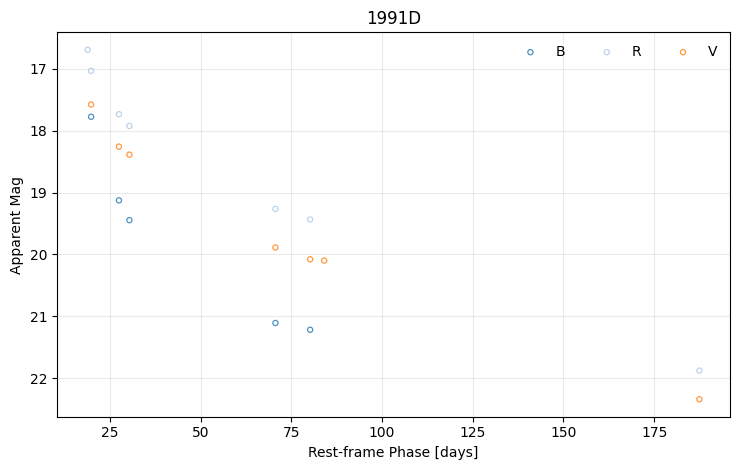

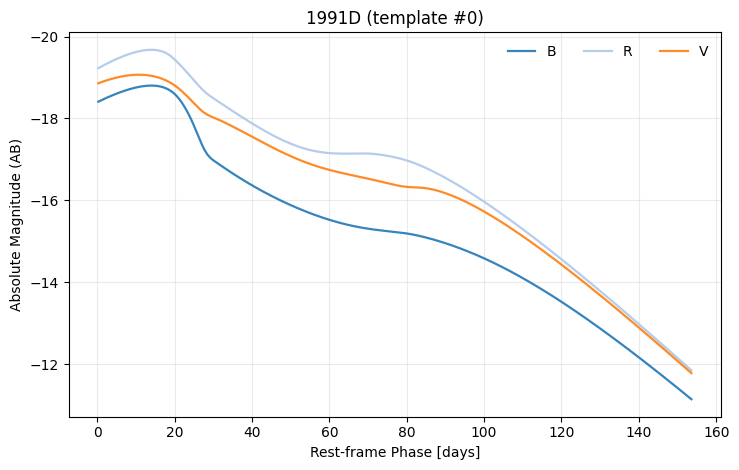

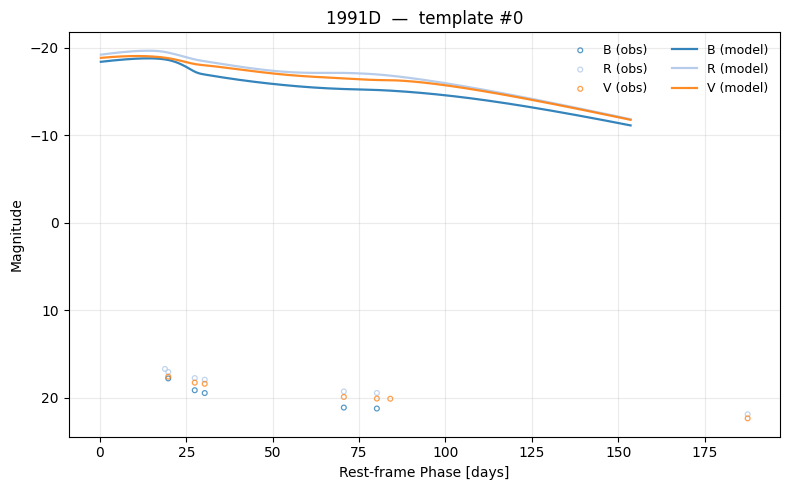

In [30]:
# =============================================================================
# Cell 6: Quick Diagnostics on One Event
# =============================================================================

try:
    # Get metadata for first event
    meta = list_t0_meta(templates_file)
    
    if meta.empty:
        print("⚠️  No metadata available. Rebuild templates.")
    else:
        event_row = meta.iloc[0]
        event_name = event_row['name']
        z = event_row.get('z', 0.5)
        t0 = event_row.get('t0_used', 57000.0)
        
        print(f"\nDiagnosing event: {event_name}")
        print(f"  z={z:.3f}, t0={t0:.1f}")
        
        # Get template index
        idx = template_index_for_event(templates_file, event_name)
        print(f"  template_idx={idx}")
        
        # Plot observations only
        plot_event_obs(
            event_name,
            per_event_dir=out_perevent,
            output_dir=str(storage_dir),
            use_phase=True,
            z=z,
            t0=t0,
            scale_to_peak=False
        )
        
        # Plot model only
        plot_event_model(
            templates_file,
            output_dir=str(storage_dir),
            template_idx=idx,
            use_log_time=False
        )
        
        # Overlay obs + model
        plot_event_obs_vs_model(
            event_name,
            output_dir=str(storage_dir),
            per_event_dir=out_perevent,
            templates_file=templates_file,
            template_idx=idx,
            use_phase=True,
            z=z,
            t0=t0,
            bands=None,  # Auto-detect available bands
            scale_to_peak=False
        )

except Exception as e:
    print(f"❌ Error: {type(e).__name__}: {e}")
    import traceback
    traceback.print_exc()

Available bands:
  CSV: ['B', 'R', 'V']
  Template: ['B', 'R', 'V']
  Common: ['B', 'V', 'R']
[abs-from-templates] m_obs - (M_abs + DM) [mag]:
      N    median      mean       std
band                                 
B     5 -0.000171 -0.000718  0.006937
R     7 -0.000297 -0.394446  1.012468
V     7 -0.000254 -0.326983  0.865063
Global median: -0.0002902635774368889


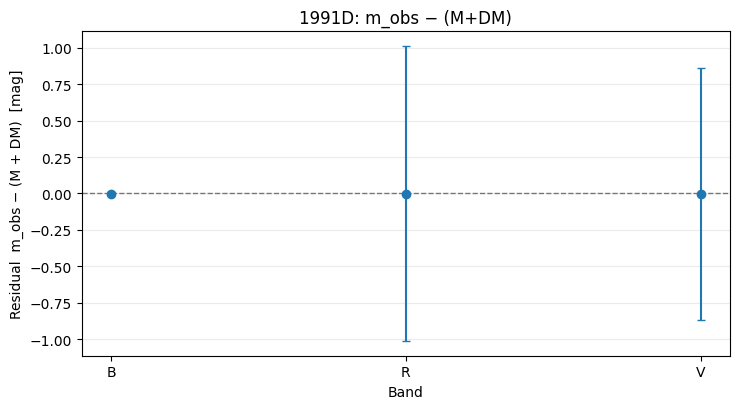

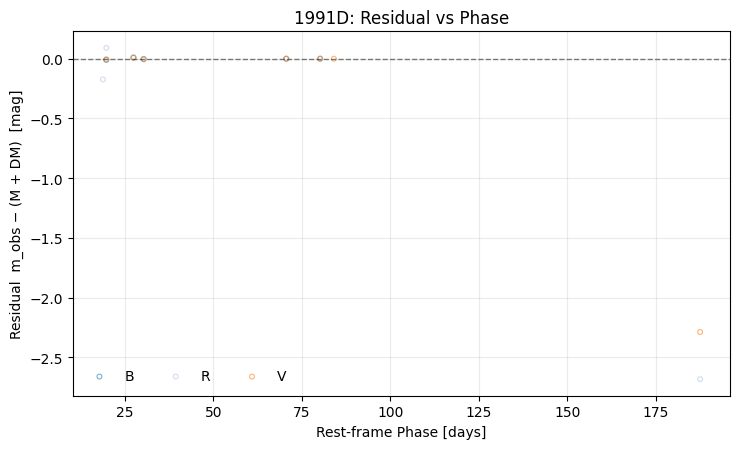

In [42]:
# =============================================================================
# Cell 7: Residual Diagnostics (Robust Version)
# =============================================================================

# Get available bands from CSV
csv_bands = list_event_bands(out_perevent, event_name)
tpl_bands = list_template_bands(templates_file, idx)

print(f"Available bands:")
print(f"  CSV: {csv_bands}")
print(f"  Template: {tpl_bands}")

# Find common bands
common_bands = list(set(csv_bands) & set(tpl_bands))
print(f"  Common: {common_bands}")

if not common_bands:
    print(f"\n  No overlapping bands between CSV and template!")
else:
    # Check m_obs vs (M_template + DM)
    df_res = diagnose_abs_from_templates(
        event_name,
        out_perevent,
        templates_file,
        idx,
        z=z,
        t0=t0,
        bands=common_bands,  #  Use only overlapping bands
        return_with_phase=True,
        verbose=True
    )
    
    if not df_res.empty:
        plot_residuals(df_res, by_band=True, title=f"{event_name}: m_obs − (M+DM)")
        plot_residuals(df_res, vs_phase=True, title=f"{event_name}: Residual vs Phase")
    else:
        print("  No residuals computed")

In [44]:
# =============================================================================
# Quick Test for different band sets
# =============================================================================

# Check first 5 events to see band variety
for i in range(min(5, len(meta))):
    evt = meta.iloc[i]
    name = evt['name']
    bands = list_event_bands(out_perevent, name)
    print(f"{name:15s}: {bands}")

1991D          : ['B', 'R', 'V']
1999as         : ['B', 'I', 'R', 'V']
2002gh         : ['B', 'I', 'V']
2005ap         : ['B', 'I', 'R', 'V']
2006oz         : ['g', 'i', 'r', 'u', 'z']


Saved to /Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe/SLSNe_den_3e-08_d_None-None_Mpc_z_0.001-0.3_ext_True_kcor_False_z_0.001-0.3_rate_3e-08_templates_coverage_summary.csv

261 templates loaded
Bands per template: count    261.000000
mean       5.919540
std        3.319702
min        1.000000
25%        4.000000
50%        5.000000
75%        7.000000
max       21.000000
Name: n_bands, dtype: float64
Phase coverage: count    240.000000
mean     116.023164
std       26.441545
min       32.601806
25%      104.534878
50%      121.475584
75%      135.807058
max      155.572248
Name: phase_span, dtype: float64
Most common bands: bands
g,i,r,z                34
cyan,g,i,orange,r      31
cyan,g,orange,r        16
g,i,r                  12
G,cyan,g,i,orange,r    11
Name: count, dtype: int64


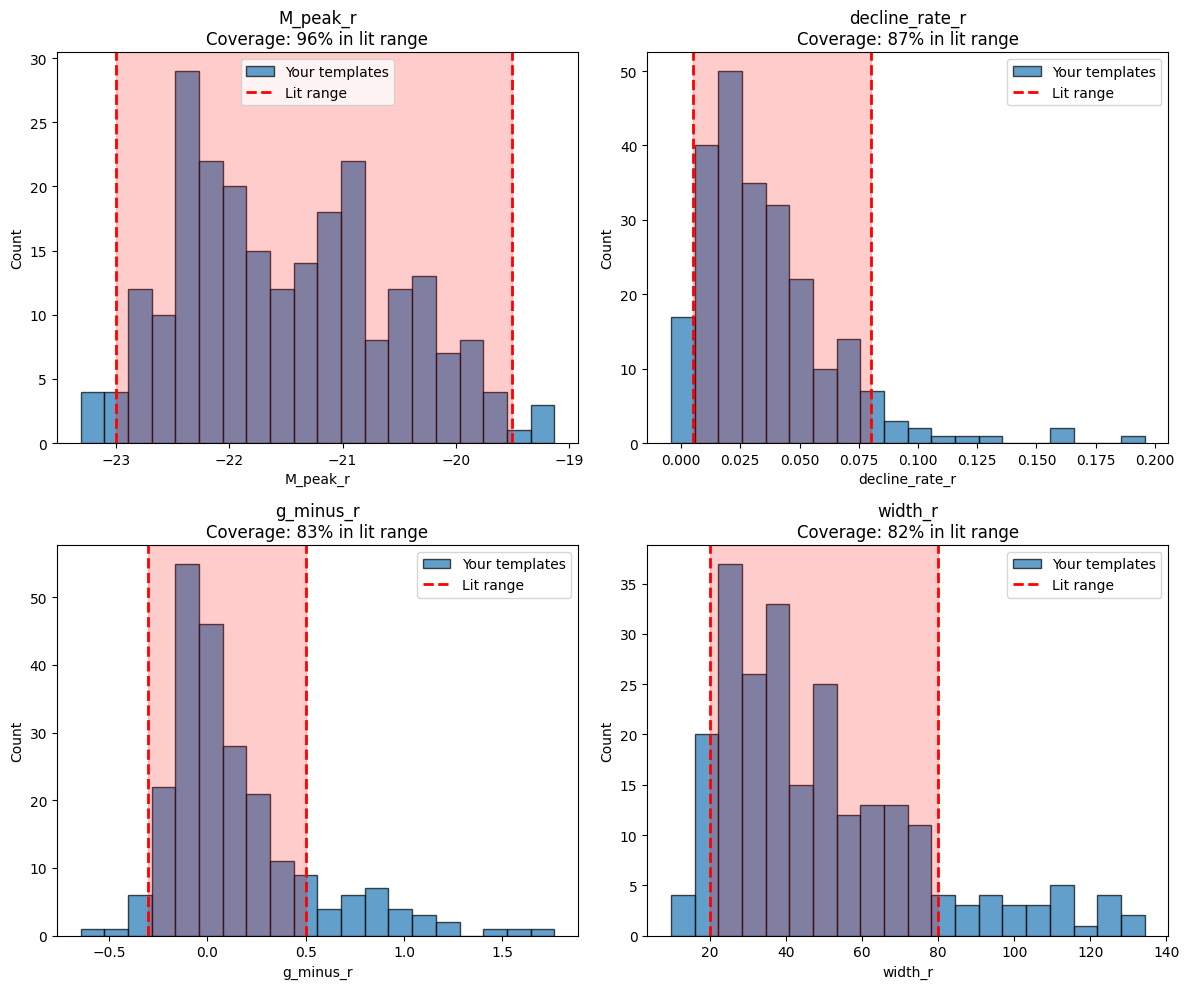


=== Coverage Assessment ===
M_peak_r            : good
decline_rate_r      : good
g_minus_r           : good
width_r             : good
Fast evolvers (>0.05 mag/day): 57
Slow evolvers (<0.02 mag/day): 79
Very bright (M_r < -22): 87
Faint (M_r > -20.5): 41
Blue (g-r < -0.1): 56
Red (g-r > 0.3): 49

✓ Good coverage across major SLSN types


In [45]:
# =============================================================================
# Cell 8: Template Coverage Analysis
# =============================================================================

# Characterize all templates
df_cov = characterize_template_coverage(templates_file, save_summary=True)

print(f"\n{len(df_cov)} templates loaded")
print(f"Bands per template: {df_cov['n_bands'].describe()}")
print(f"Phase coverage: {df_cov['phase_span'].describe()}")
print(f"Most common bands: {df_cov['bands'].value_counts().head()}")

# Compute physical properties
df_cov_full = compute_slsn_properties(df_cov, templates_file)

# Compare to literature
gaps = assess_literature_coverage(df_cov_full)

# Find missing archetypes
missing = find_missing_archetypes(df_cov_full)




 [BUILD] Generating population...
  Overwriting existing population (GENERATE_NEW_POPULATION=True)
  Time window: 1 to 3652 days (relative to mjd0=60980.5)
  Rate density: 3.0e-08 Mpc^-3 yr^-1
  Redshift range: 0.001 - 0.3
Valid templates: 165/261
[INFO] z_min = 0.00100 -> d_min = 4.429832647675932 Mpc
[INFO] z_max = 0.30000 -> d_max = 1232.706667272352661 Mpc
Simulating 2420 SLSNe (rate=3.0e-08 Mpc^-3 yr^-1)
[GAL LAT CUT] Applied |b| > 15° cut:
  Before: 2420 events
  After:  1779 events (73.5% retained)
  Removed 641 events near Galactic plane
Distance range: 99.1 - 1232.5 Mpc
Mean distance: 926.9 Mpc
Peak times: 1 to 3652 days


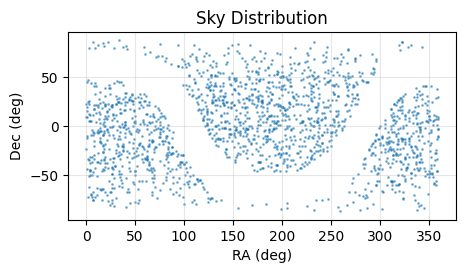

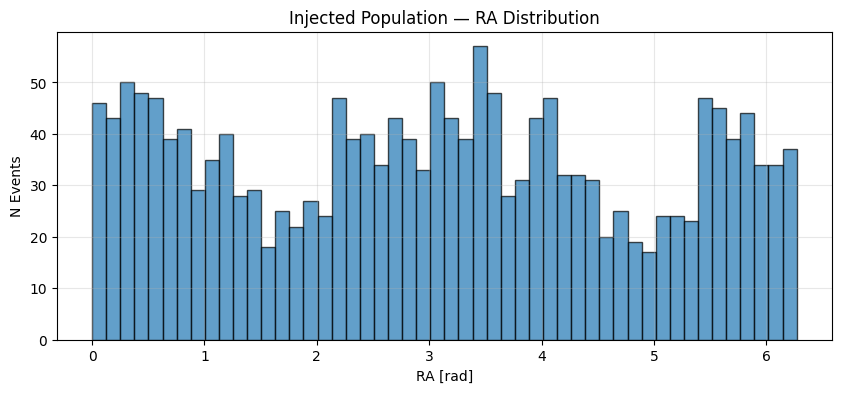

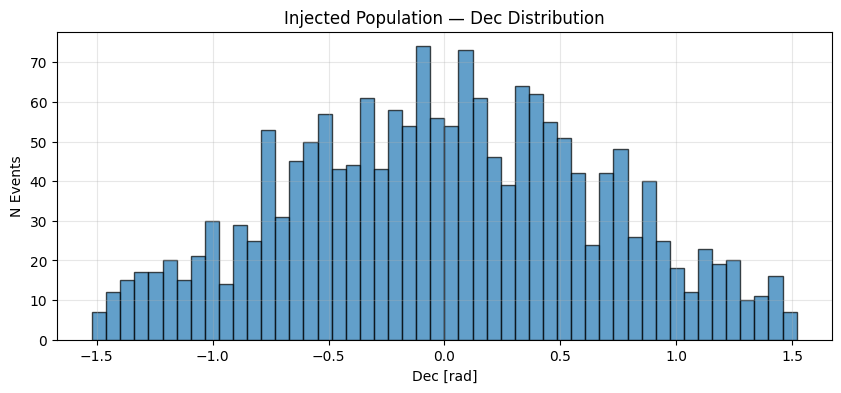

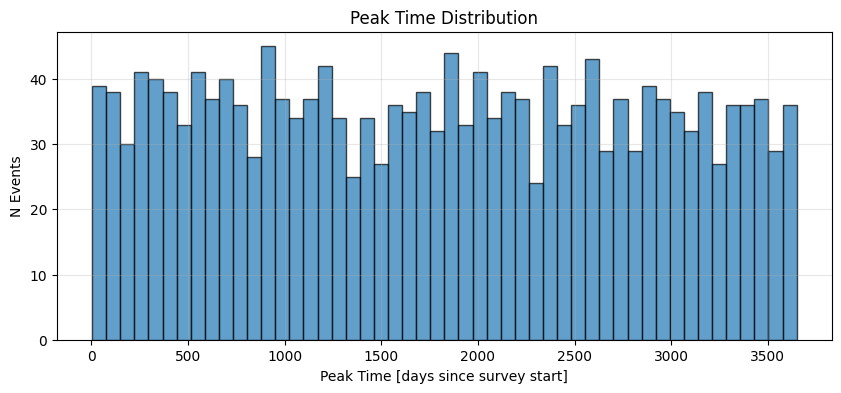

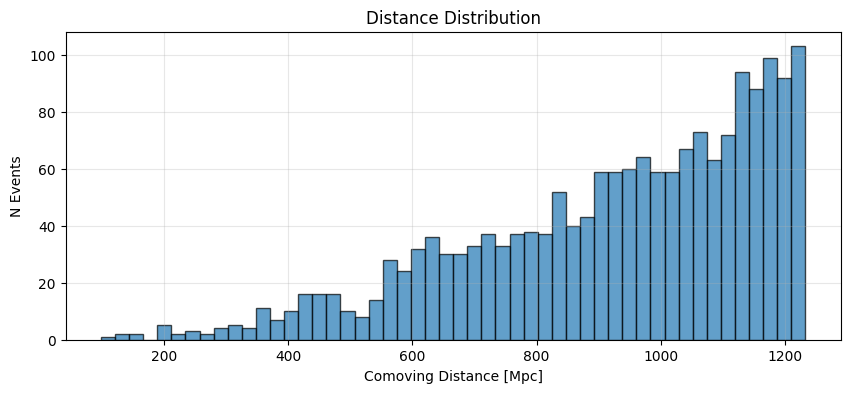

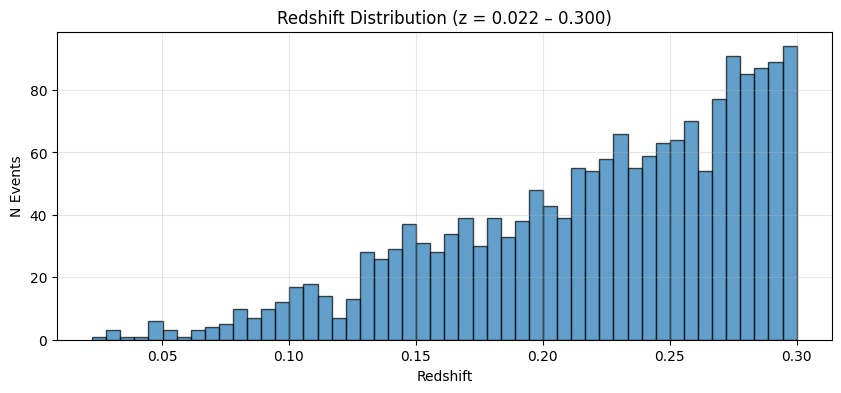

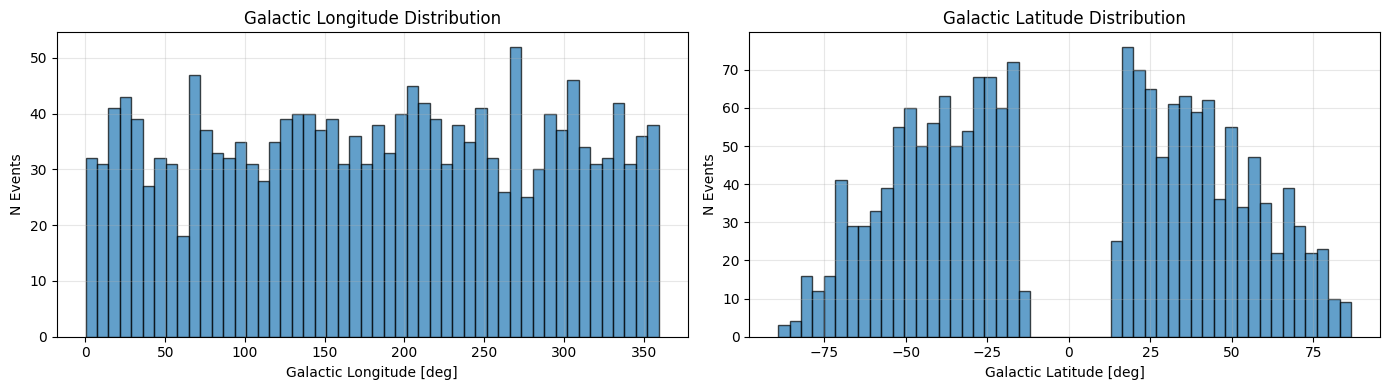

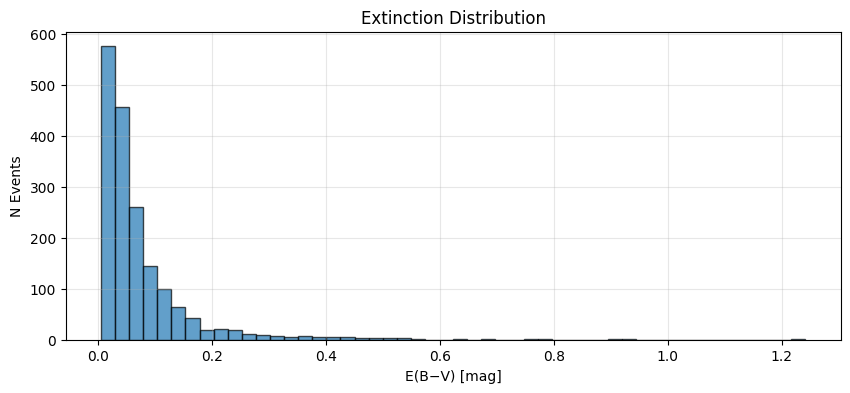

[INFO] Saved atomically to /Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe/SLSNe_den_3e-08_d_None-None_Mpc_z_0.001-0.3_ext_True_kcor_False_z_0.001-0.3_rate_3e-08_population.pkl
Saved SLSN population to /Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe/SLSNe_den_3e-08_d_None-None_Mpc_z_0.001-0.3_ext_True_kcor_False_z_0.001-0.3_rate_3e-08_population.pkl

[VERIFICATION] Events with |b| < 15°: 0 (should be 0)

 Generated 1779 SLSNe
   Saved to: /Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe/SLSNe_den_3e-08_d_None-None_Mpc_z_0.001-0.3_ext_True_kcor_False_z_0.001-0.3_rate_3e-08_population.pkl
   peak_time range: 3.3 - 3649.8 days (relative)
   peak_mjd range (with mjd0=60980.5): 60983.8 - 64630.3


In [50]:
# =============================================================================
# Cell 9: Generate Population
# =============================================================================

if GENERATE_NEW_POPULATION or not pop_file.exists():
    print(f"\n [BUILD] Generating population...")
    if GENERATE_NEW_POPULATION and pop_file.exists():
        print(f"  Overwriting existing population (GENERATE_NEW_POPULATION=True)")
    
    print(f"  Time window: {t_start} to {t_end} days (relative to mjd0={mjd0})")
    print(f"  Rate density: {rate_density:.1e} Mpc^-3 yr^-1")
    print(f"  Redshift range: {z_min} - {z_max}")
    
    slicer = generate_SLSN_PopSlicer(
        lc_model=templates,
        t_start=t_start,              # From Cell 2
        t_end=t_end,                  # From Cell 2
        z_min=z_min,                  # From Cell 2
        z_max=z_max,                  # From Cell 2
        rate_density=rate_density,
        gal_lat_cut = gal_lat_cut, # From Cell 2
        seed=seed,                    # From Cell 2
        save_to=pop_file,
        make_debug_plots=make_debug_plots,
    )
    
    print(f"\n Generated {len(slicer.slice_points['z'])} SLSNe")
    print(f"   Saved to: {pop_file}")
    print(f"   peak_time range: {slicer.slice_points['peak_time'].min():.1f} - {slicer.slice_points['peak_time'].max():.1f} days (relative)")
    print(f"   peak_mjd range (with mjd0={mjd0}): {mjd0 + slicer.slice_points['peak_time'].min():.1f} - {mjd0 + slicer.slice_points['peak_time'].max():.1f}")
else:
    print(f"\n[LOAD] Loading existing population...")
    print(f" Loaded {len(slicer.slice_points['z'])} SLSNe")
    print(f"   From: {pop_file}")
    print(f"   (Set GENERATE_NEW_POPULATION=True in Cell 2 to regenerate)")
    
    # Show info
    print(f"\n  peak_time range: {slicer.slice_points['peak_time'].min():.1f} - {slicer.slice_points['peak_time'].max():.1f} days")
    print(f"  peak_mjd range (with mjd0={mjd0}): {mjd0 + slicer.slice_points['peak_time'].min():.1f} - {mjd0 + slicer.slice_points['peak_time'].max():.1f}")


In [52]:
# =============================================================================
# Cell 9.5: Debug OpSim Database (FIXED)
# =============================================================================

db_path = db_dir / f"{cadence}.db"

if not db_path.exists():
    raise FileNotFoundError(f"OpSim database not found: {db_path}")

# Extract actual survey info from database
conn = sqlite3.connect(str(db_path))
cursor = conn.cursor()

cursor.execute("SELECT MIN(observationStartMJD), MAX(observationStartMJD) FROM observations")
db_mjd_min, db_mjd_max = cursor.fetchone()

cursor.execute("SELECT COUNT(*) FROM observations")
n_obs = cursor.fetchone()[0]

cursor.execute("SELECT DISTINCT filter FROM observations ORDER BY filter")
filters = [row[0] for row in cursor.fetchall()]

conn.close()

# Compare with our parameters
print(f"📊 Database Info: {cadence}")
print(f"  File: {db_path.name} ({db_path.stat().st_size / 1e9:.2f} GB)")
print(f"  Observations: {n_obs:,}")
print(f"  Filters: {filters}")
print(f"  Database MJD range: {db_mjd_min:.1f} to {db_mjd_max:.1f}")
print(f"  Database duration: {(db_mjd_max - db_mjd_min)/365.25:.1f} years")

print(f"\n🔧 Your Parameters (from Cell 2):")
print(f"  mjd0 (survey start): {mjd0}")
print(f"  Event window: {t_start} to {t_end} days")
print(f"  Population MJD range: {mjd0 + t_start:.1f} to {mjd0 + t_end:.1f}")

# Validation
pop_mjd_min = mjd0 + slicer.slice_points['peak_time'].min()
pop_mjd_max = mjd0 + slicer.slice_points['peak_time'].max()

galb = slicer.slice_points['galb']

print(f"\nGalactic Latitude Parameters:")
print(f"Galactic latitude range: {galb.min():.1f}° to {galb.max():.1f}°")
print(f"Events with |b| < 15°: {np.sum(np.abs(galb) < 15)} (should be 0)")
print(f"Events with |b| > 15°: {np.sum(np.abs(galb) > 15)} (should be all)")
print(f"Events with 15° < |b| < 30°: {np.sum((np.abs(galb) > 15) & (np.abs(galb) < 30))}")
print(f"Events with |b| > 30°: {np.sum(np.abs(galb) > 30)}")

print(f"\n✅ Validation:")
if abs(mjd0 - db_mjd_min) > 1.0:
    print(f"  ⚠️  WARNING: mjd0={mjd0} doesn't match database start {db_mjd_min:.1f}")
    print(f"     Consider updating Cell 2: mjd0={db_mjd_min}")
else:
    print(f"  ✅ mjd0 matches database start")

if pop_mjd_max < db_mjd_min or pop_mjd_min > db_mjd_max:
    print(f"  ❌ ERROR: Population doesn't overlap with survey!")
    print(f"     Update Cell 2 parameters")
elif pop_mjd_min < db_mjd_min or pop_mjd_max > db_mjd_max:
    print(f"  ⚠️  WARNING: Partial overlap - some events outside survey")
    if pop_mjd_min < db_mjd_min:
        print(f"     {db_mjd_min - pop_mjd_min:.1f} days before survey starts")
    if pop_mjd_max > db_mjd_max:
        print(f"     {pop_mjd_max - db_mjd_max:.1f} days after survey ends")
else:
    overlap_years = (min(pop_mjd_max, db_mjd_max) - max(pop_mjd_min, db_mjd_min)) / 365.25
    print(f"  ✅ Full overlap: {overlap_years:.1f} years")
    print(f"  ✅ Population peak MJDs: {pop_mjd_min:.1f} to {pop_mjd_max:.1f}")

📊 Database Info: baseline_v4.3.1_10yrs
  File: baseline_v4.3.1_10yrs.db (0.75 GB)
  Observations: 2,015,728
  Filters: ['g', 'i', 'r', 'u', 'y', 'z']
  Database MJD range: 60980.0 to 64632.3
  Database duration: 10.0 years

🔧 Your Parameters (from Cell 2):
  mjd0 (survey start): 60980.5
  Event window: 1 to 3652 days
  Population MJD range: 60981.5 to 64632.5

Galactic Latitude Parameters:
Galactic latitude range: -89.2° to 86.7°
Events with |b| < 15°: 0 (should be 0)
Events with |b| > 15°: 1779 (should be all)
Events with 15° < |b| < 30°: 573
Events with |b| > 30°: 1206

✅ Validation:
  ✅ mjd0 matches database start
  ✅ Full overlap: 10.0 years
  ✅ Population peak MJDs: 60983.8 to 64630.3


   Loading magnitude grid...
[load_magnitude_grid] Loaded with filters: ['u', 'g', 'r', 'i', 'z', 'y']

SLSN Detection Metric - Full Diagnostics
Database dir: /Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub
Cadences: ['baseline_v4.3.1_10yrs']
Population: 1779 SLSNe
Output dir: /Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe
 Database verified: baseline_v4.3.1_10yrs.db (0.75 GB)

Running cadence: baseline_v4.3.1_10yrs

Results for baseline_v4.3.1_10yrs:
  Events simulated: 1779
  Events detected:  90 (5.1%)
  Avg filters/detection: 5.2
  Avg observations/detection: 41.3
  Saved: /Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe/slsn_detect_baseline_v4.3.1_10yrs.csv
  Saved: /Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe/local_efficiency_baseline_v4.3.1_10yrs.csv
Filter testing.....
[diag] injected_peak_ebv_ma

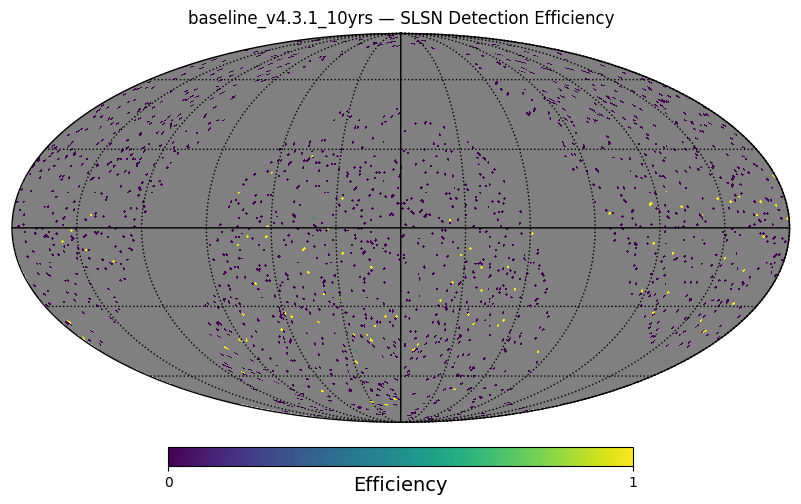

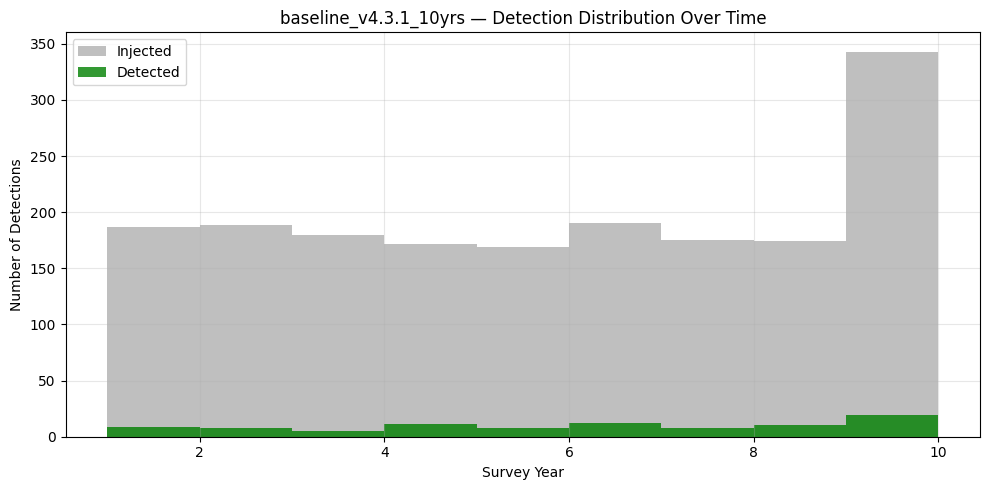

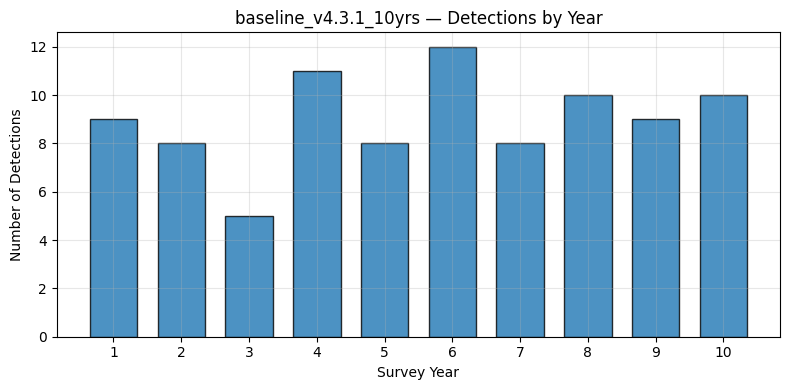

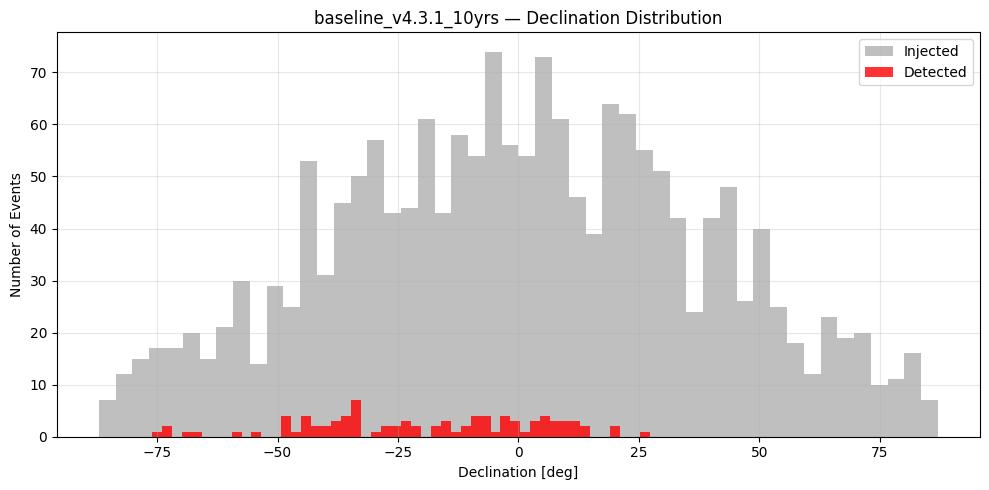

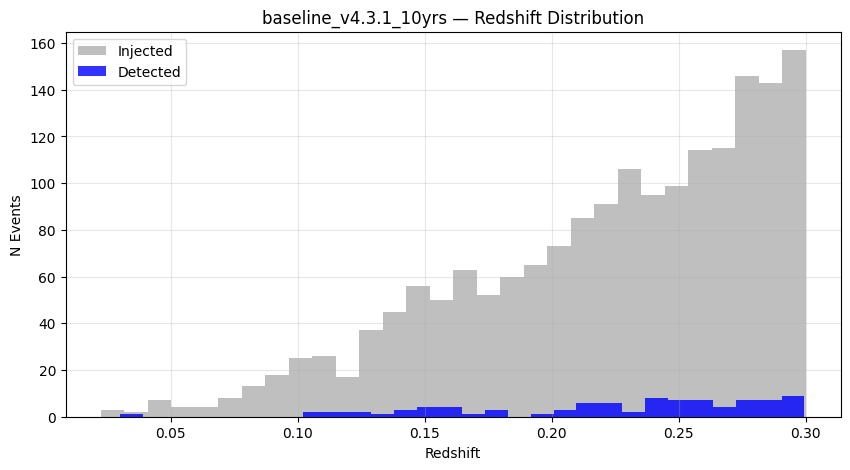

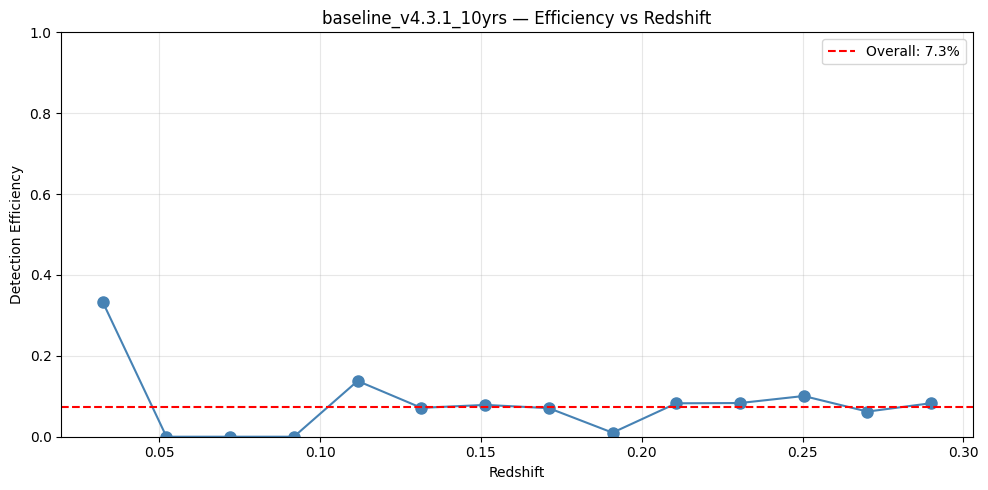

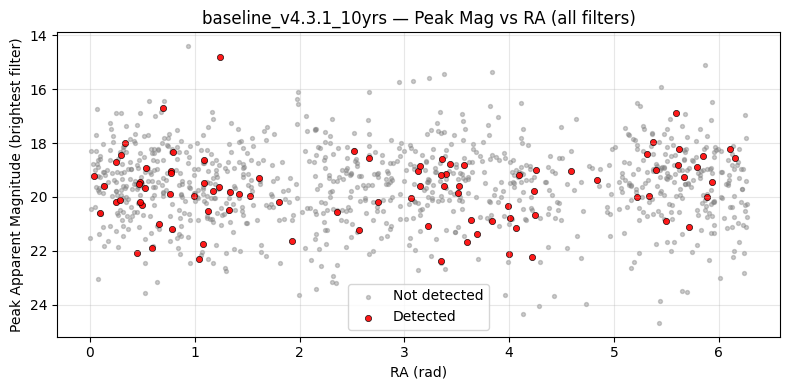

[diag] Using minimum magnitude across all filters for each event


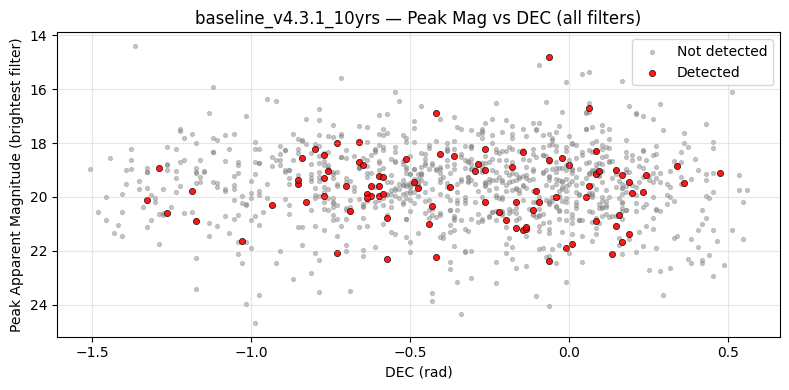

[diag] finite first_det_mjd: 1036
[diag] per_filter_min_mag present: True
[diag] finite observed-peak (r): 875
[diag] finite injected-peak (r): 840


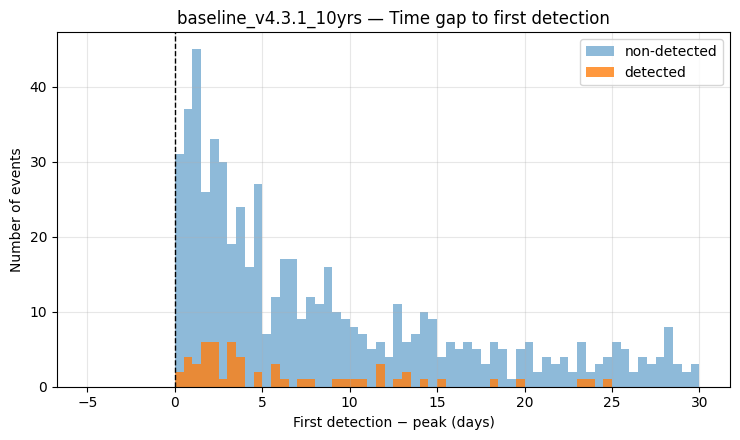

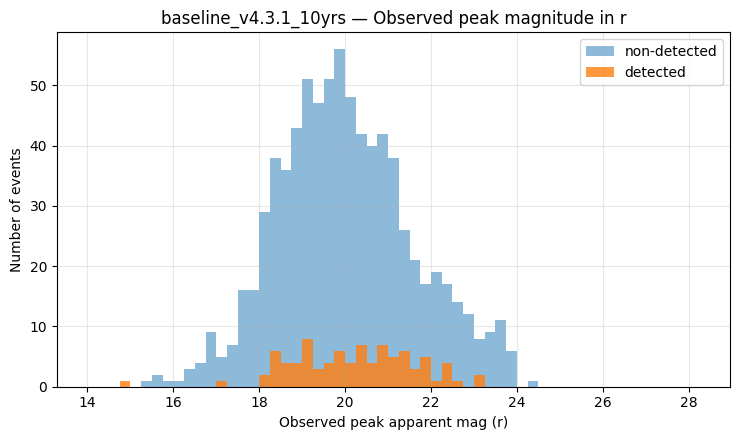

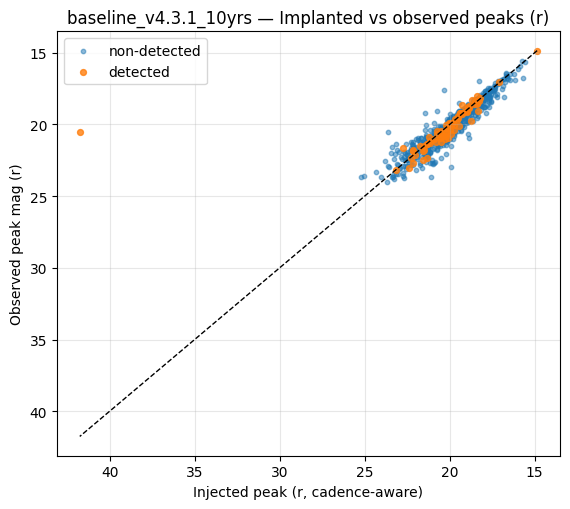

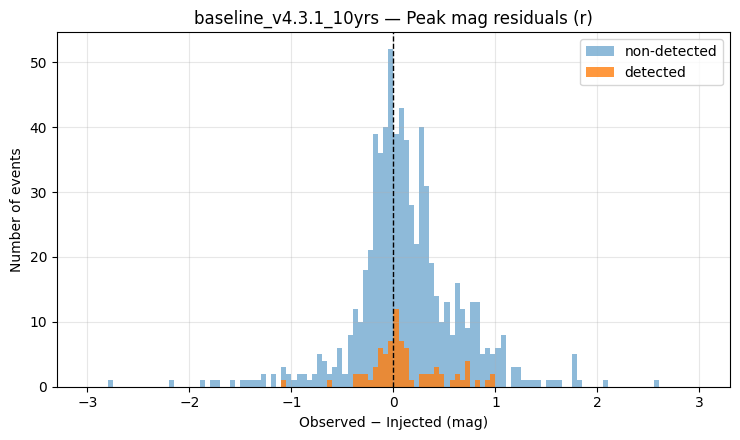

   Saved diagnostic plots
[CLEANUP] Removing temp directory: /Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe/Metric_temp_baseline_v4.3.1_10yrs

Results Summary

baseline_v4.3.1_10yrs:
  Detected: 90/1,234 (7.3%)
  z range (detected): 0.030 - 0.300
  Avg detections/event: 41.3
  Avg filters/event: 5.2

 Generated outputs in /Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe:
  - baseline_v4.3.1_10yrs_efficiency_healpix.png
  - baseline_v4.3.1_10yrs_time_distribution.png
  - baseline_v4.3.1_10yrs_dec_distribution.png
  - baseline_v4.3.1_10yrs_z_analysis.png
  - slsn_detect_baseline_v4.3.1_10yrs.csv
  - local_efficiency_baseline_v4.3.1_10yrs.csv


In [54]:
# =============================================================================
# Cell 10: Run Detection Metric (CORRECTED PATHS)
# =============================================================================

# Verify mag grid loaded
if not hasattr(templates, 'mag_grid') or not templates.mag_grid:
    print("   Loading magnitude grid...")
    templates.load_magnitude_grid("/Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe/SLSNe_den_3e-08_d_None-None_Mpc_z_0.001-0.3_ext_True_kcor_False_z_0.001-0.3_rate_3e-08_templates_mag_grid.pkl")

# CORRECTED: OpSim DB is in Multi_Transient_Metrics_Hub, not a subdirectory
db_dir = Path("/Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub")
cadences = ['baseline_v4.3.1_10yrs']

print(f"\n{'='*60}")
print(f"SLSN Detection Metric - Full Diagnostics")
print(f"{'='*60}")
print(f"Database dir: {db_dir}")
print(f"Cadences: {cadences}")
print(f"Population: {len(slicer.slice_points['z'])} SLSNe")
print(f"Output dir: {storage_dir}")

# Verify database exists before running
db_path = db_dir / f"{cadences[0]}.db"
if not db_path.exists():
    raise FileNotFoundError(f"OpSim database not found: {db_path}")

print(f" Database verified: {db_path.name} ({db_path.stat().st_size / 1e9:.2f} GB)")

# Run detection with all diagnostics
results, metric = run_slsn_detect(
    templates=templates,
    population=slicer,
    cadences=cadences,
    db_dir=str(db_dir),
    output_dir=str(storage_dir),
    store_obs_mode="full",
    mjd0=mjd0,
    ignore_triples=ignore_triples,
    save_csv=save_csv,
    make_plots=make_plots,
    clean_temp=clean_temp,
    verbose=verbose
)

# Summary
print(f"\n{'='*60}")
print(f"Results Summary")
print(f"{'='*60}")

for cadence, df_obs in results.items():
    n_det = df_obs['detected'].sum()
    n_total = len(df_obs)
    
    print(f"\n{cadence}:")
    print(f"  Detected: {n_det:,}/{n_total:,} ({100*n_det/n_total:.1f}%)")
    
    if n_det > 0:
        det = df_obs[df_obs['detected'] == 1]
        print(f"  z range (detected): {det['z'].min():.3f} - {det['z'].max():.3f}")
        print(f"  Avg detections/event: {det['n_observations_detected'].mean():.1f}")
        print(f"  Avg filters/event: {det['n_filters_detected'].mean():.1f}")
    else:
        print(f"  Zero detections - check Cell 9.5 debug output")

print(f"\n Generated outputs in {storage_dir}:")
print(f"  - {cadences[0]}_efficiency_healpix.png")
print(f"  - {cadences[0]}_time_distribution.png")
print(f"  - {cadences[0]}_dec_distribution.png")
print(f"  - {cadences[0]}_z_analysis.png")
print(f"  - slsn_detect_{cadences[0]}.csv")
print(f"  - local_efficiency_{cadences[0]}.csv")


Running All Three SLSN Metrics

Running cadence: baseline_v4.3.1_10yrs
  Running SLSN_Detect_Metric...
    Efficiency: 5.1% (90/1779)


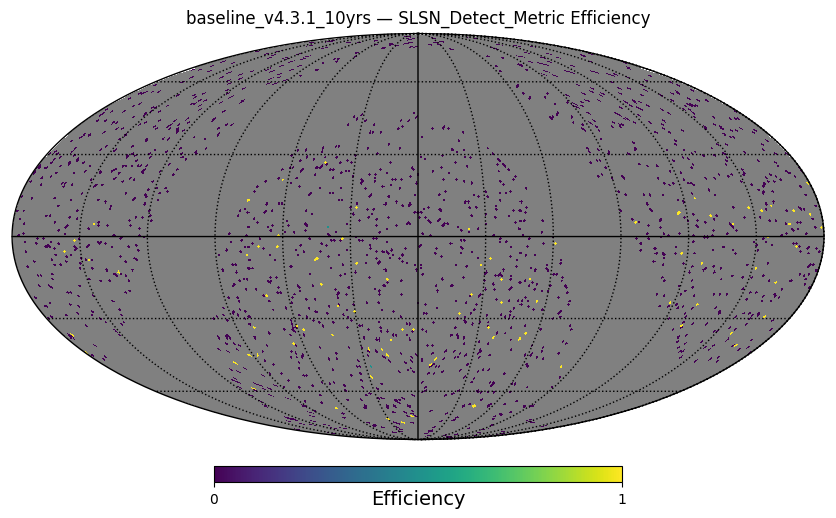

  Running SLSN_CharacterizeMetric...
    Efficiency: 2.1% (37/1779)


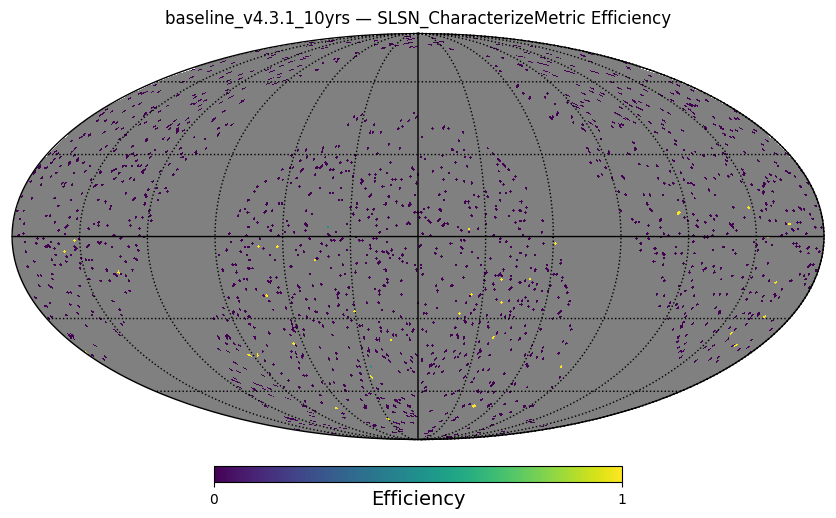

  Running SLSN_SpecTriggerMetric...
    Efficiency: 1.9% (34/1779)


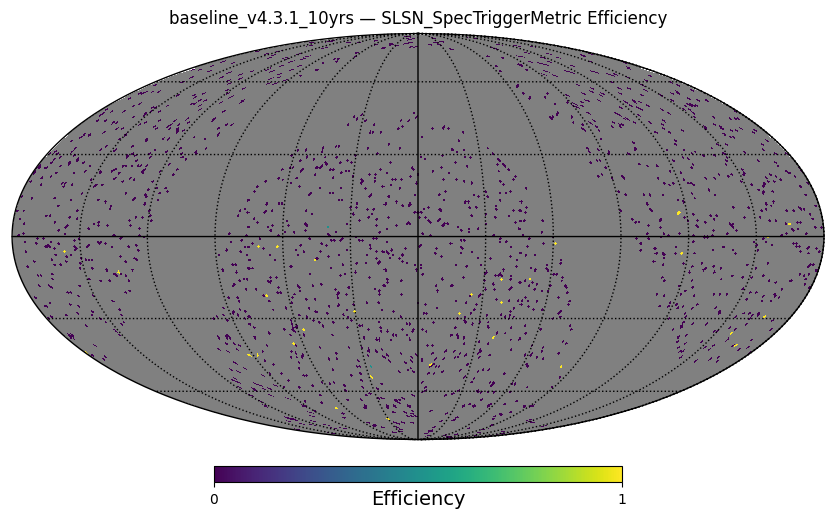


Summary saved: /Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe/slsn_multi_metrics_summary.csv

Summary: All Three Metrics
                 cadence                   metric  n_events  n_success  \
0  baseline_v4.3.1_10yrs       SLSN_Detect_Metric      1779         90   
1  baseline_v4.3.1_10yrs  SLSN_CharacterizeMetric      1779         37   
2  baseline_v4.3.1_10yrs   SLSN_SpecTriggerMetric      1779         34   

   efficiency  
0    0.050590  
1    0.020798  
2    0.019112  

 Summary saved to /Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe/all_metrics_summary.csv


In [56]:
# =============================================================================
# Cell 11: Run All Three Metrics
# =============================================================================

from slsn_metrics import (
    run_slsn_multi_metrics,
    SLSN_Detect_Metric,
    SLSN_CharacterizeMetric, 
    SLSN_SpecTriggerMetric
)

print("\n" + "="*60)
print("Running All Three SLSN Metrics")
print("="*60)

# Create all three metrics
metrics_list = [
    SLSN_Detect_Metric(lc_model=templates, mjd0=mjd0, store_obs_mode="none"),
    SLSN_CharacterizeMetric(lc_model=templates, mjd0=mjd0, store_obs_mode="none"),
    SLSN_SpecTriggerMetric(lc_model=templates, mjd0=mjd0, store_obs_mode="none")
]

# Run all metrics
summary_df = run_slsn_multi_metrics(
    templates=templates,
    population=slicer,
    cadences=cadences,
    db_dir=str(db_dir),
    output_dir=str(storage_dir),
    metrics_list=metrics_list,
    mjd0=mjd0,
    ignore_triples=ignore_triples,
    save_summary=True,
    make_plots=True,  # This will make HEALPix maps
    verbose=True
)

# Display results
print("\n" + "="*60)
print("Summary: All Three Metrics")
print("="*60)
print(summary_df)

# Save summary
summary_path = storage_dir / "all_metrics_summary.csv"
summary_df.to_csv(summary_path, index=False)
print(f"\n Summary saved to {summary_path}")

In [60]:
#NEED TO ADD TO MODULES AS A WAY TO MANIPULATE OR SEE THE LARGE DFs 

print("df_obs shape:", df_obs.shape)
print("\nFirst 20 columns:\n", list(df_obs.columns)[:20])

# Full column listing (sorted)
cols = sorted(df_obs.columns)
print("\nALL columns (sorted):")
for c in cols:
    print(" -", c)

# Peek at a few rows
display(df_obs.head(3))

# Check for columns you care about
for name in ["sid","template_idx","tmpl_idx","distance_modulus","DM","mjd0","peak_time",
             "per_filter_min_mag","mjd_obs","mag_obs","snr_obs"]:
    print(f"{name:24} ->", name in df_obs.columns)


df_obs shape: (1234, 29)

First 20 columns:
 ['sid', 'mjd_obs', 'mag_obs', 'snr_obs', 'filter', 'available_bands', 'detected', 'file_indx', 'z', 'ra', 'dec', 'distance_Mpc', 'ebv', 'distance', 'distance_modulus', 'peak_time', 'n_observations_detected', 'n_filters_detected', 'eval_peak_mag', 'first_det_mjd']

ALL columns (sorted):
 - available_bands
 - dec
 - detected
 - distance
 - distance_Mpc
 - distance_modulus
 - ebv
 - eval_peak_mag
 - file_indx
 - filter
 - first_det_mjd
 - injected_peak_ebv_mag_g_cadence
 - injected_peak_ebv_mag_i_cadence
 - injected_peak_ebv_mag_r_cadence
 - injected_peak_ebv_mag_u_cadence
 - injected_peak_ebv_mag_y_cadence
 - injected_peak_ebv_mag_z_cadence
 - mag_obs
 - mjd_obs
 - n_filters_detected
 - n_observations_detected
 - peak_mjd
 - peak_time
 - per_filter_min_mag
 - ra
 - sid
 - snr_obs
 - year
 - z


,sid,mjd_obs,mag_obs,snr_obs,filter,available_bands,detected,file_indx,z,ra,...,first_det_mjd,per_filter_min_mag,year,peak_mjd,injected_peak_ebv_mag_g_cadence,injected_peak_ebv_mag_i_cadence,injected_peak_ebv_mag_r_cadence,injected_peak_ebv_mag_u_cadence,injected_peak_ebv_mag_y_cadence,injected_peak_ebv_mag_z_cadence
0,1,"[61768.14688157732, 62762.38980058189, 63917.2...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[g, z, u, z, u, g, i, i, i, g, z, u, i, g, z, ...","cyan,g,i,orange,r",False,104,0.223448,0.613592,...,63226.114845,"{'u': nan, 'g': nan, 'r': nan, 'i': 20.2812370...",7,63224.243036,NaN,20.280637,NaN,NaN,NaN,NaN
1,2,"[62428.19464959029, 63614.12519691358, 62428.2...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[y, z, y, i, z, i, g, r, r, i, z, r, g, z, i, ...","B,UVM2,UVW1,UVW2,V,g,i,r,u,z",False,13,0.283925,1.116738,...,NaN,"{'u': nan, 'g': nan, 'r': nan, 'i': nan, 'z': ...",5,62614.503533,NaN,NaN,NaN,NaN,NaN,NaN
2,3,"[63061.06628977819, 64526.04139265308, 63117.0...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[u, y, g, y, i, r, r, r, z, z, i, r, i, r, r, ...","B,H,I,J,K,R,U,UVM2,UVW1,UVW2,V,W1,W2,g,i,orang...",True,31,0.263485,4.000622,...,62560.364439,"{'u': nan, 'g': nan, 'r': nan, 'i': 22.1945013...",4,62436.952241,23.302093,NaN,23.361457,NaN,NaN,22.134698


sid                      -> True
template_idx             -> False
tmpl_idx                 -> False
distance_modulus         -> True
DM                       -> False
mjd0                     -> False
peak_time                -> True
per_filter_min_mag       -> True
mjd_obs                  -> True
mag_obs                  -> True
snr_obs                  -> True


In [62]:
import numpy as np

#NEED TO ADD TO MODULES AS A WAY TO MANIPULATE OR SEE THE LARGE DFs 

def peek_slice_points(sp, label="slice_points", max_show=50):
    print(f"\n[{label}] type:", type(sp))
    if sp is None:
        return
    # Common cases
    if isinstance(sp, dict):
        keys = list(sp.keys())
        print(f"keys ({len(keys)}):", keys[:max_show], "..." if len(keys) > max_show else "")
        # show a few shapes/types
        for k in keys[:max_show]:
            v = sp[k]
            shape = getattr(v, "shape", None)
            dtype = getattr(v, "dtype", None)
            print(f"  - {k:20} type={type(v).__name__:12} shape={shape} dtype={dtype}")
    elif isinstance(sp, (np.recarray, np.ndarray)) and sp.dtype.names:
        names = sp.dtype.names
        print(f"fields ({len(names)}):", names[:max_show], "..." if len(names) > max_show else "")
        for n in names[:max_show]:
            v = sp[n]
            shape = getattr(v, "shape", None)
            print(f"  - {n:20} type={type(v).__name__:12} shape={shape} dtype={v.dtype}")
    else:
        # Last resort: dir()
        print("Attributes (dir):")
        attrs = [a for a in dir(sp) if not a.startswith("_")]
        print(attrs)

# Try slicer, then population
try:
    peek_slice_points(slicer.slice_points, label="slicer.slice_points")
except Exception as e:
    print("[warn] slicer.slice_points not accessible:", e)

try:
    peek_slice_points(population.slice_points, label="population.slice_points")
except Exception as e:
    print("[warn] population.slice_points not accessible:", e)



[slicer.slice_points] type: <class 'dict'>
keys (35): ['sid', 'ra', 'dec', 'gall', 'galb', 'z', 'distance', 'distance_modulus', 'peak_time', 'file_indx', 'ebv', 'A_u', 'A_g', 'A_r', 'A_i', 'A_z', 'A_y', 'peak_mag_abs_u', 'peak_app_mag_noebv_u', 'peak_app_mag_ebv_u', 'peak_mag_abs_g', 'peak_app_mag_noebv_g', 'peak_app_mag_ebv_g', 'peak_mag_abs_r', 'peak_app_mag_noebv_r', 'peak_app_mag_ebv_r', 'peak_mag_abs_i', 'peak_app_mag_noebv_i', 'peak_app_mag_ebv_i', 'peak_mag_abs_z', 'peak_app_mag_noebv_z', 'peak_app_mag_ebv_z', 'peak_mag_abs_y', 'peak_app_mag_noebv_y', 'peak_app_mag_ebv_y'] 
  - sid                  type=ndarray      shape=(1779,) dtype=int64
  - ra                   type=ndarray      shape=(1779,) dtype=float64
  - dec                  type=ndarray      shape=(1779,) dtype=float64
  - gall                 type=ndarray      shape=(1779,) dtype=float64
  - galb                 type=ndarray      shape=(1779,) dtype=float64
  - z                    type=ndarray      shape=(1779,) d

=== DEC Distribution Analysis ===
Injected DEC range: -87.1° to 32.8°
Detected DEC range: -76.1° to 27.3°

Rubin optimal footprint: -75° to +15°
Your detected range matches? False

Events injected outside Rubin footprint: 170 (13.8%)
Events detected outside Rubin footprint: 4
=== Galactic Coordinate Check ===
Galactic latitude (b) range: -89.2° to 86.7°
Galactic longitude (l) range: 0.1° to 359.5°


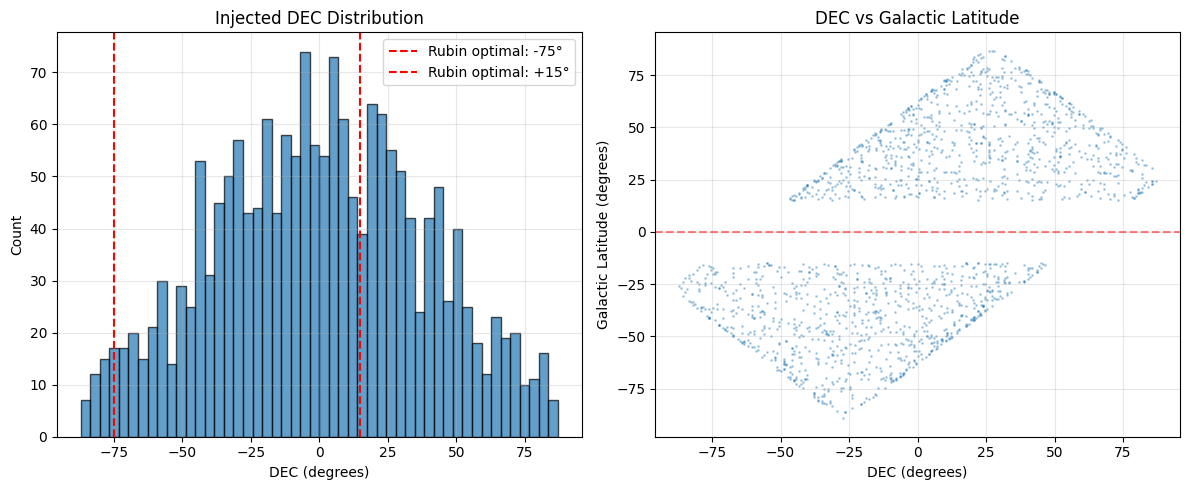

Events with |b| < 10°: 0 (0.0%)
Events with |b| < 15°: 0 (0.0%)
Events with |b| < 20°: 209 (11.7%)
Events with |b| < 30°: 573 (32.2%)

=== Population slice_points keys ===
  A_g: ndarray with 1779 elements
  A_i: ndarray with 1779 elements
  A_r: ndarray with 1779 elements
  A_u: ndarray with 1779 elements
  A_y: ndarray with 1779 elements
  A_z: ndarray with 1779 elements
  dec: ndarray with 1779 elements
  distance: ndarray with 1779 elements
  distance_modulus: ndarray with 1779 elements
  ebv: ndarray with 1779 elements
  file_indx: ndarray with 1779 elements
  galb: ndarray with 1779 elements
  gall: ndarray with 1779 elements
  peak_app_mag_ebv_g: ndarray with 1779 elements
  peak_app_mag_ebv_i: ndarray with 1779 elements
  peak_app_mag_ebv_r: ndarray with 1779 elements
  peak_app_mag_ebv_u: ndarray with 1779 elements
  peak_app_mag_ebv_y: ndarray with 1779 elements
  peak_app_mag_ebv_z: ndarray with 1779 elements
  peak_app_mag_noebv_g: ndarray with 1779 elements
  peak_app_mag_

In [63]:
import numpy as np

# NEED TO ADD TO DIAGNOSTICS 


# After running run_slsn_detect
df_obs = results['baseline_v4.3.1_10yrs']  # or whatever your cadence name is

# Convert DEC to degrees for clarity
all_dec_deg = np.degrees(df_obs['dec'].values)
detected_dec_deg = np.degrees(df_obs.loc[df_obs['detected']==1, 'dec'].values)

print("=== DEC Distribution Analysis ===")
print(f"Injected DEC range: {all_dec_deg.min():.1f}° to {all_dec_deg.max():.1f}°")
print(f"Detected DEC range: {detected_dec_deg.min():.1f}° to {detected_dec_deg.max():.1f}°")
print(f"\nRubin optimal footprint: -75° to +15°")
print(f"Your detected range matches? {-75 <= detected_dec_deg.min() <= -60 and 0 <= detected_dec_deg.max() <= 20}")

# Check how many events fall outside observable range
outside = (all_dec_deg < -75) | (all_dec_deg > 15)
print(f"\nEvents injected outside Rubin footprint: {outside.sum()} ({100*outside.sum()/len(df_obs):.1f}%)")
print(f"Events detected outside Rubin footprint: {df_obs.loc[outside, 'detected'].sum()}")

import numpy as np

# Check for galactic coordinates in population
if 'galb' in slicer.slice_points:
    galb = slicer.slice_points['galb']
    gall = slicer.slice_points['gall']
    dec_deg = np.degrees(slicer.slice_points['dec'])
    
    print("=== Galactic Coordinate Check ===")
    print(f"Galactic latitude (b) range: {galb.min():.1f}° to {galb.max():.1f}°")
    print(f"Galactic longitude (l) range: {gall.min():.1f}° to {gall.max():.1f}°")
    
    # Check correlation between DEC and galactic latitude
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Plot 1: DEC distribution
    axes[0].hist(dec_deg, bins=50, edgecolor='black', alpha=0.7)
    axes[0].axvline(-75, color='red', linestyle='--', label='Rubin optimal: -75°')
    axes[0].axvline(+15, color='red', linestyle='--', label='Rubin optimal: +15°')
    axes[0].set_xlabel('DEC (degrees)')
    axes[0].set_ylabel('Count')
    axes[0].set_title('Injected DEC Distribution')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: DEC vs Galactic latitude
    axes[1].scatter(dec_deg, galb, s=1, alpha=0.3)
    axes[1].set_xlabel('DEC (degrees)')
    axes[1].set_ylabel('Galactic Latitude (degrees)')
    axes[1].set_title('DEC vs Galactic Latitude')
    axes[1].axhline(0, color='red', linestyle='--', alpha=0.5)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Check if there's a galactic plane cut
    for cutoff in [10, 15, 20, 30]:
        in_plane = np.abs(galb) < cutoff
        print(f"Events with |b| < {cutoff}°: {in_plane.sum()} ({100*in_plane.sum()/len(galb):.1f}%)")
else:
    print("No galactic coordinates found in population")

# Also check: What's in the actual population file?
print("\n=== Population slice_points keys ===")
for key in sorted(slicer.slice_points.keys()):
    val = slicer.slice_points[key]
    if hasattr(val, '__len__'):
        print(f"  {key}: {type(val).__name__} with {len(val)} elements")
    else:
        print(f"  {key}: {type(val).__name__}")

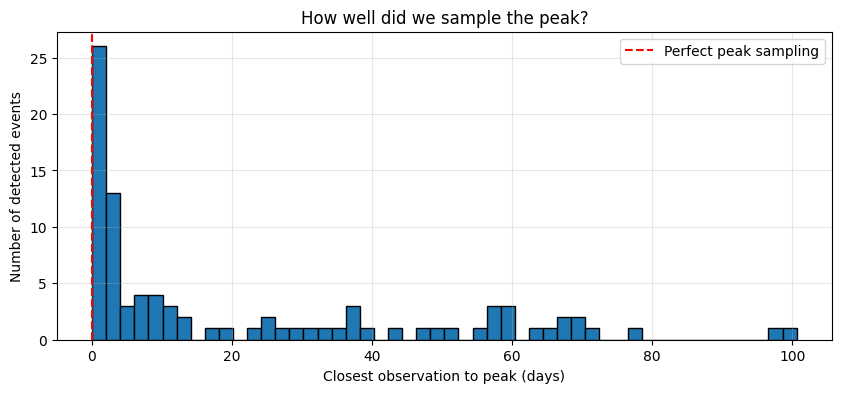

Median closest observation: 7.6 days from peak
% observed within ±5 days of peak: 44.4%


In [64]:
# After running detection
import numpy as np

# NEED TO ADD TO DIAGNOSTICS 


# For detected events, check how well we sampled the peak
detected = df_obs[df_obs['detected'] == 1]

phase_at_obs = []
for idx, row in detected.iterrows():
    sid = int(row['sid'])
    mjd_obs = np.array(row['mjd_obs'])
    peak_mjd = mjd0 + slicer.slice_points['peak_time'][sid]
    
    phases = mjd_obs - peak_mjd  # Days relative to peak
    closest_to_peak = np.abs(phases).min()
    phase_at_obs.append(closest_to_peak)

phase_at_obs = np.array(phase_at_obs)

plt.figure(figsize=(10, 4))
plt.hist(phase_at_obs, bins=50, edgecolor='black')
plt.xlabel('Closest observation to peak (days)')
plt.ylabel('Number of detected events')
plt.title('How well did we sample the peak?')
plt.axvline(0, color='red', linestyle='--', label='Perfect peak sampling')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Median closest observation: {np.median(phase_at_obs):.1f} days from peak")
print(f"% observed within ±5 days of peak: {100*np.sum(np.abs(phase_at_obs) < 5)/len(phase_at_obs):.1f}%")

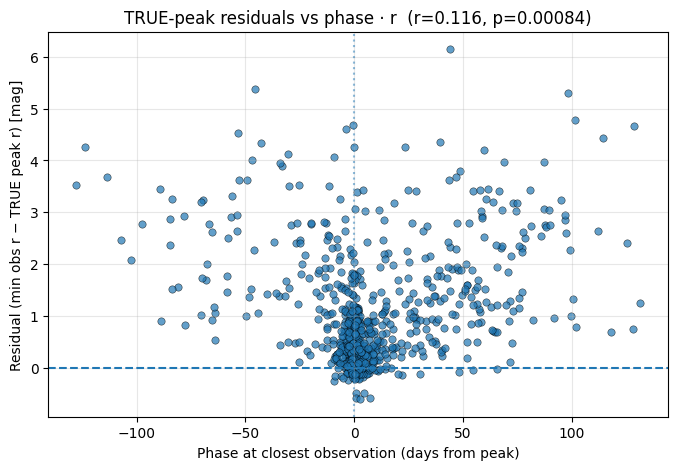

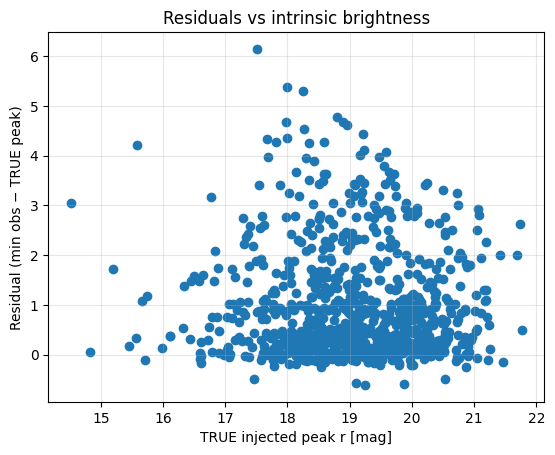

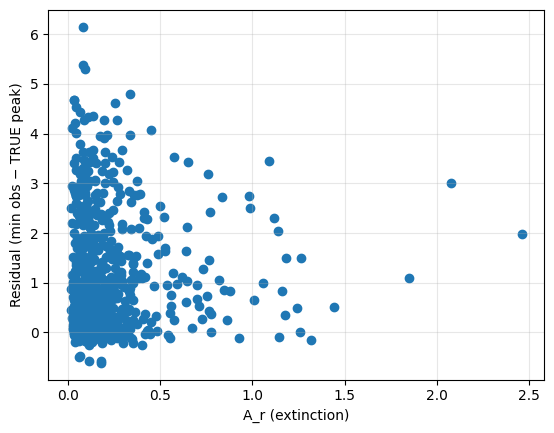

In [68]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# NEED TO ADD TO DIAGNOSTICS 

band = 'r'  # change to 'g','i',... as desired

# --- 1) Map sid -> row index inside slicer.slice_points arrays ---
sp = slicer.slice_points
sid_array = np.asarray(sp['sid'])
sid_to_ix = {int(s): i for i, s in enumerate(sid_array)}

# --- 2) TRUE (phase=0) apparent peak with extinction from slice_points ---
true_peak_arr = np.asarray(sp[f'peak_app_mag_ebv_{band}'])  # shape = (Nevents,)

def sid_to_true_peak(sid):
    ix = sid_to_ix.get(int(sid), None)
    return float(true_peak_arr[ix]) if ix is not None else np.nan

df_obs[f'injected_peak_TRUE_{band}'] = df_obs['sid'].map(sid_to_true_peak)

# --- 3) Residual vs TRUE peak: (min observed in band) - (TRUE peak) ---
def min_obs_mag(row, band=band):
    d = row.get('per_filter_min_mag', {})
    return d.get(band, np.nan)

df_obs[f'residual_vs_true_peak_{band}'] = df_obs.apply(
    lambda r: min_obs_mag(r, band) - r[f'injected_peak_TRUE_{band}'], axis=1
)

# --- 4) Phase at closest observation to peak_mjd (no need for mjd0) ---
def phase_at_closest_obs(row):
    T = np.asarray(row.get('mjd_obs', []), float)
    if T.size == 0 or not np.isfinite(row.get('peak_mjd', np.nan)):
        return np.nan
    ph = T - float(row['peak_mjd'])
    return float(ph[np.nanargmin(np.abs(ph))]) if ph.size else np.nan

if 'phase_at_closest_obs' not in df_obs.columns:
    df_obs['phase_at_closest_obs'] = df_obs.apply(phase_at_closest_obs, axis=1)

# --- 5) Plot residuals vs phase (this one should show phase dependence) ---
m = np.isfinite(df_obs['phase_at_closest_obs']) & np.isfinite(df_obs[f'residual_vs_true_peak_{band}'])
x = df_obs.loc[m, 'phase_at_closest_obs'].values
y = df_obs.loc[m, f'residual_vs_true_peak_{band}'].values
r, p = (pearsonr(x, y) if x.size > 2 else (np.nan, np.nan))

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x, y, s=28, alpha=0.7, edgecolors='black', linewidths=0.4)
ax.axhline(0, ls='--')
ax.axvline(0, ls=':', alpha=0.5)
ax.set_xlabel('Phase at closest observation (days from peak)')
ax.set_ylabel(f'Residual (min obs {band} − TRUE peak {band}) [mag]')
ax.set_title(f'TRUE-peak residuals vs phase · {band}  (r={r:.3f}, p={p:.2g})')
ax.grid(alpha=0.3)
plt.show()

plt.scatter(df_obs[f'injected_peak_TRUE_{band}'], df_obs[f'residual_vs_true_peak_{band}'])
plt.xlabel(f'TRUE injected peak {band} [mag]')
plt.ylabel('Residual (min obs − TRUE peak)')
plt.title('Residuals vs intrinsic brightness')
plt.grid(alpha=0.3)
plt.show()

plt.scatter(sp['A_r'][[sid_to_ix[s] for s in df_obs['sid']]],
            df_obs[f'residual_vs_true_peak_{band}'])
plt.xlabel('A_r (extinction)')
plt.ylabel('Residual (min obs − TRUE peak)')
plt.grid(alpha=0.3)
plt.show()


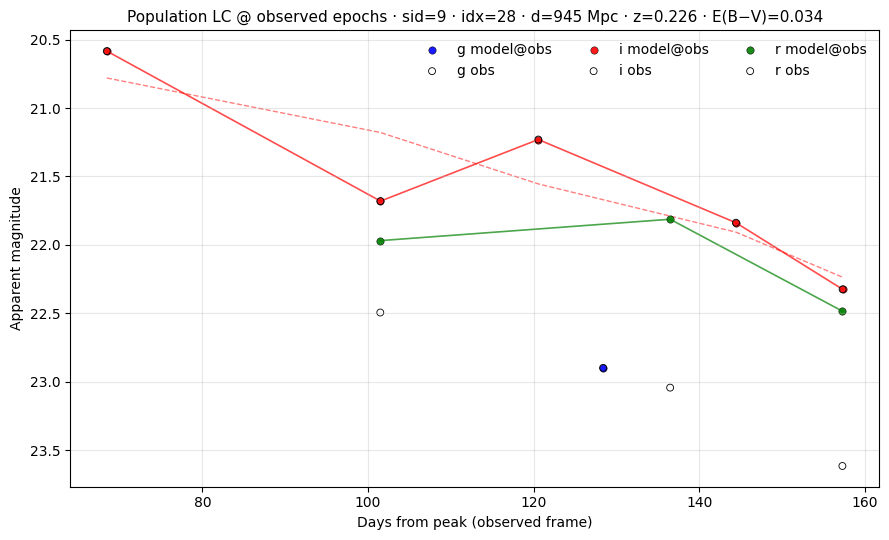

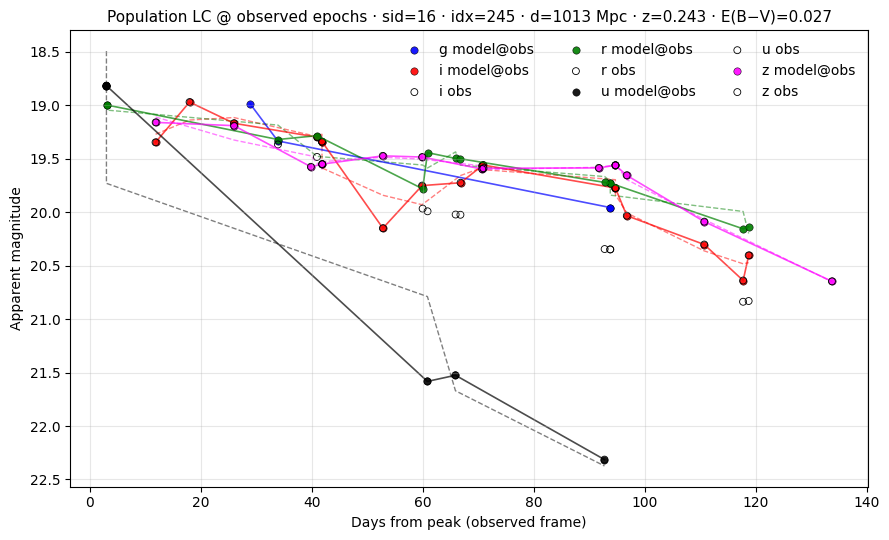

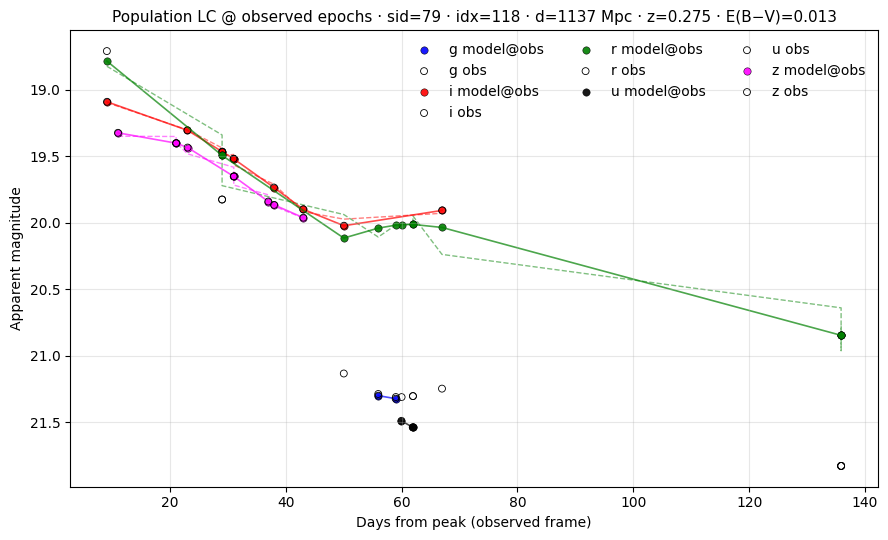

{'sid': 79,
 'model_at_obs': {'g': (array([62852.1346708 , 62855.12061426]),
   array([21.30001066, 21.32253264])),
  'i': (array([62827.1503845 , 62839.15317001, 62825.17977512, 62846.18849654,
          62834.10671734, 62863.13748673, 62825.17933118, 62827.15127937,
          62819.179978  , 62805.29169243]),
   array([19.51991487, 19.89935677, 19.4666621 , 20.02300202, 19.73581928,
          19.90783648, 19.46665013, 19.51993917, 19.30603028, 19.09177686])),
  'r': (array([62858.09941748, 62932.01462754, 62932.01149249, 62932.00835659,
          62932.00521985, 62825.15562186, 62846.16435593, 62856.13999833,
          62863.11340826, 62825.15517722, 62858.10031038, 62852.11061779,
          62805.26691207, 62855.144837  ]),
   array([20.01321638, 20.84696076, 20.84683217, 20.84670353, 20.84657487,
          19.49501482, 20.11573814, 20.01482087, 20.03593485, 19.49499316,
          20.01321764, 20.04097554, 18.78557432, 20.0185258 ])),
  'u': (array([62858.07384993, 62856.11346408, 6

In [70]:


sid1 = int(df_obs.loc[df_obs['detected']].iloc[1]['sid'])
sid2 = int(df_obs.loc[df_obs['detected']].iloc[2]['sid'])
sid5 = int(df_obs.loc[df_obs['detected']].iloc[5]['sid'])

plot_population_lc_at_obs(
    sid1, df_obs, slicer, templates,
    bands="auto",               # <-- automatically detects available bands
    apply_time_dilation=True,
    overlay_observations=True, connect_points=True,
    smooth_visual=True
)

plot_population_lc_at_obs(
    sid2, df_obs, slicer, templates,
    bands="auto",               # <-- automatically detects available bands
    apply_time_dilation=True,
    overlay_observations=True, connect_points=True,
    smooth_visual=True
)

plot_population_lc_at_obs(
    sid5, df_obs, slicer, templates,
    bands="auto",               # <-- automatically detects available bands
    apply_time_dilation=True,
    overlay_observations=True, connect_points=True,
    smooth_visual=True
)
# # Multiple events overlaid (auto-bands)
# det_sids = df_obs.loc[df_obs['detected'], 'sid'].head(3).tolist()
# plot_population_lc_multi_at_obs(det_sids, df_obs, slicer, templates,
#                                 overlap=True, bands="g", connect_points=True, smooth_visual=False)

# # # Beginning with ~2 slides of introduction to MAF (explain some history, cite a few of the papers, etc.)
# # Then state the goal: you are working towards including catalog SLSNe (and afterwords simulated models) into MAF to get rate estimates
# # To-do this, need to get the catalog SLSNe (from Seb's paper, as you describe) 

Detected: 39  |  Non-detected: 165


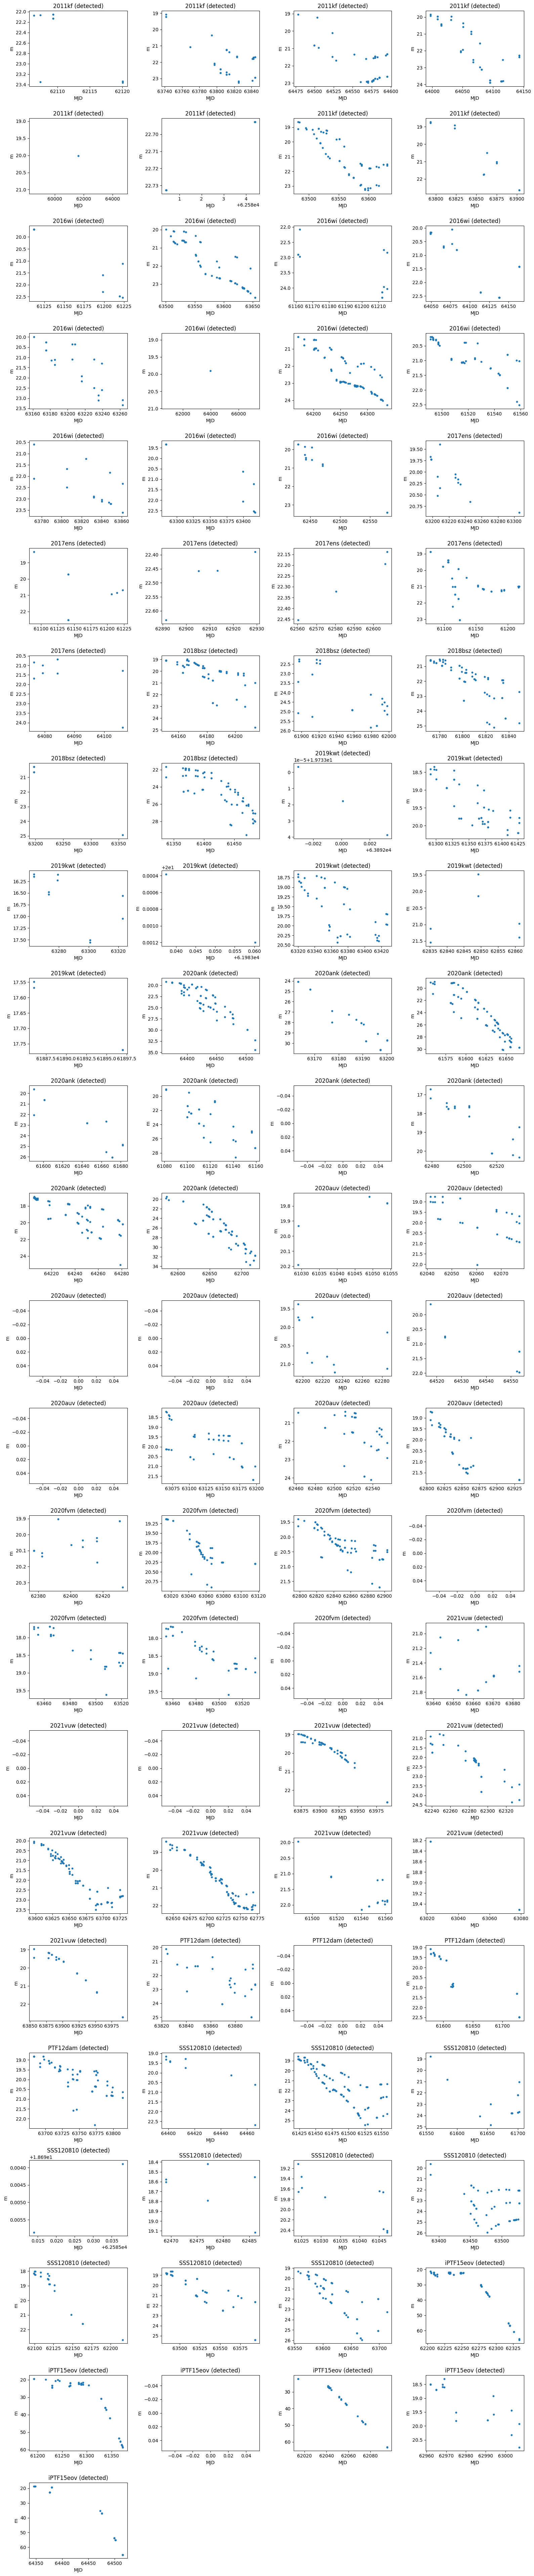

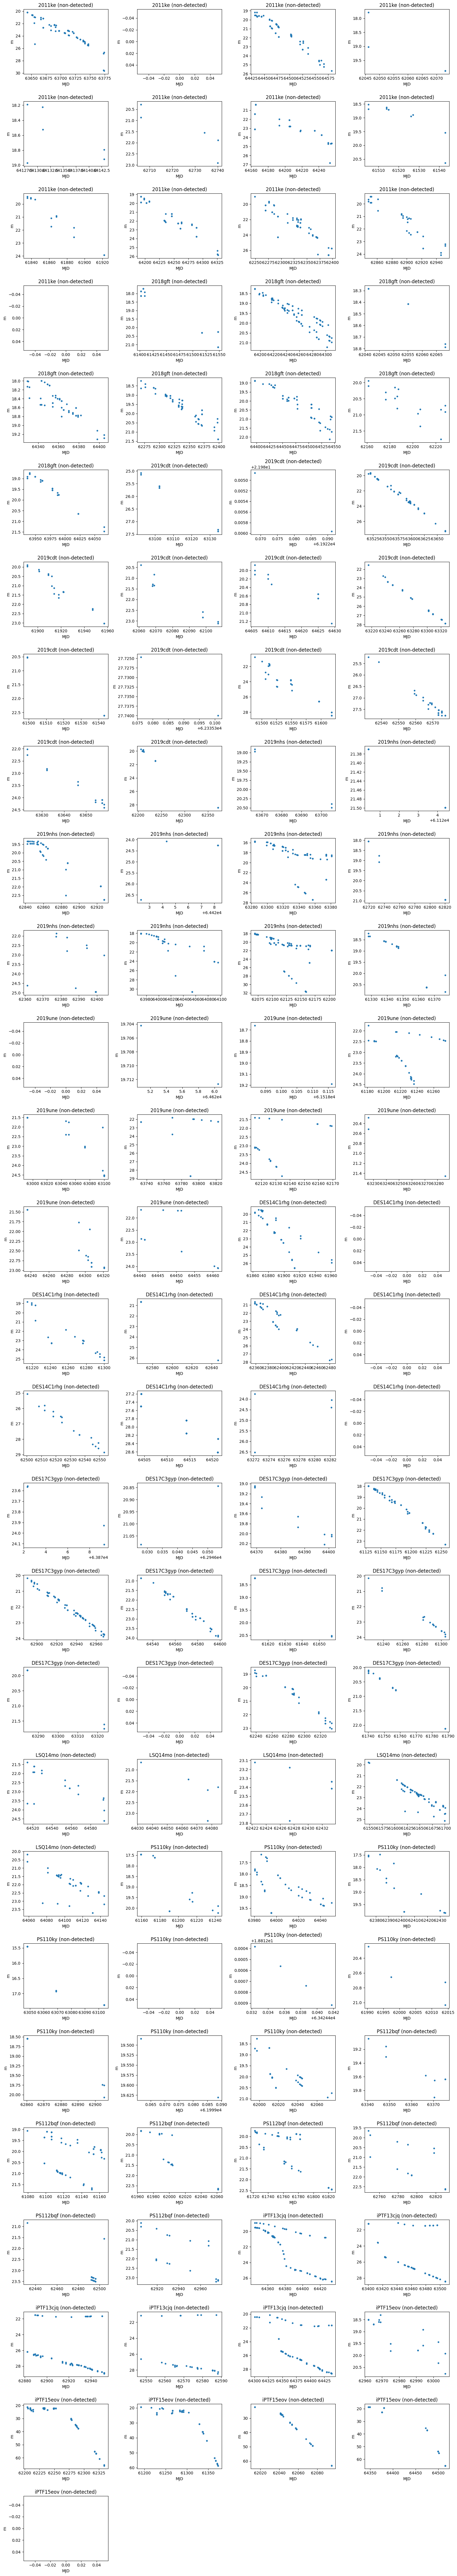

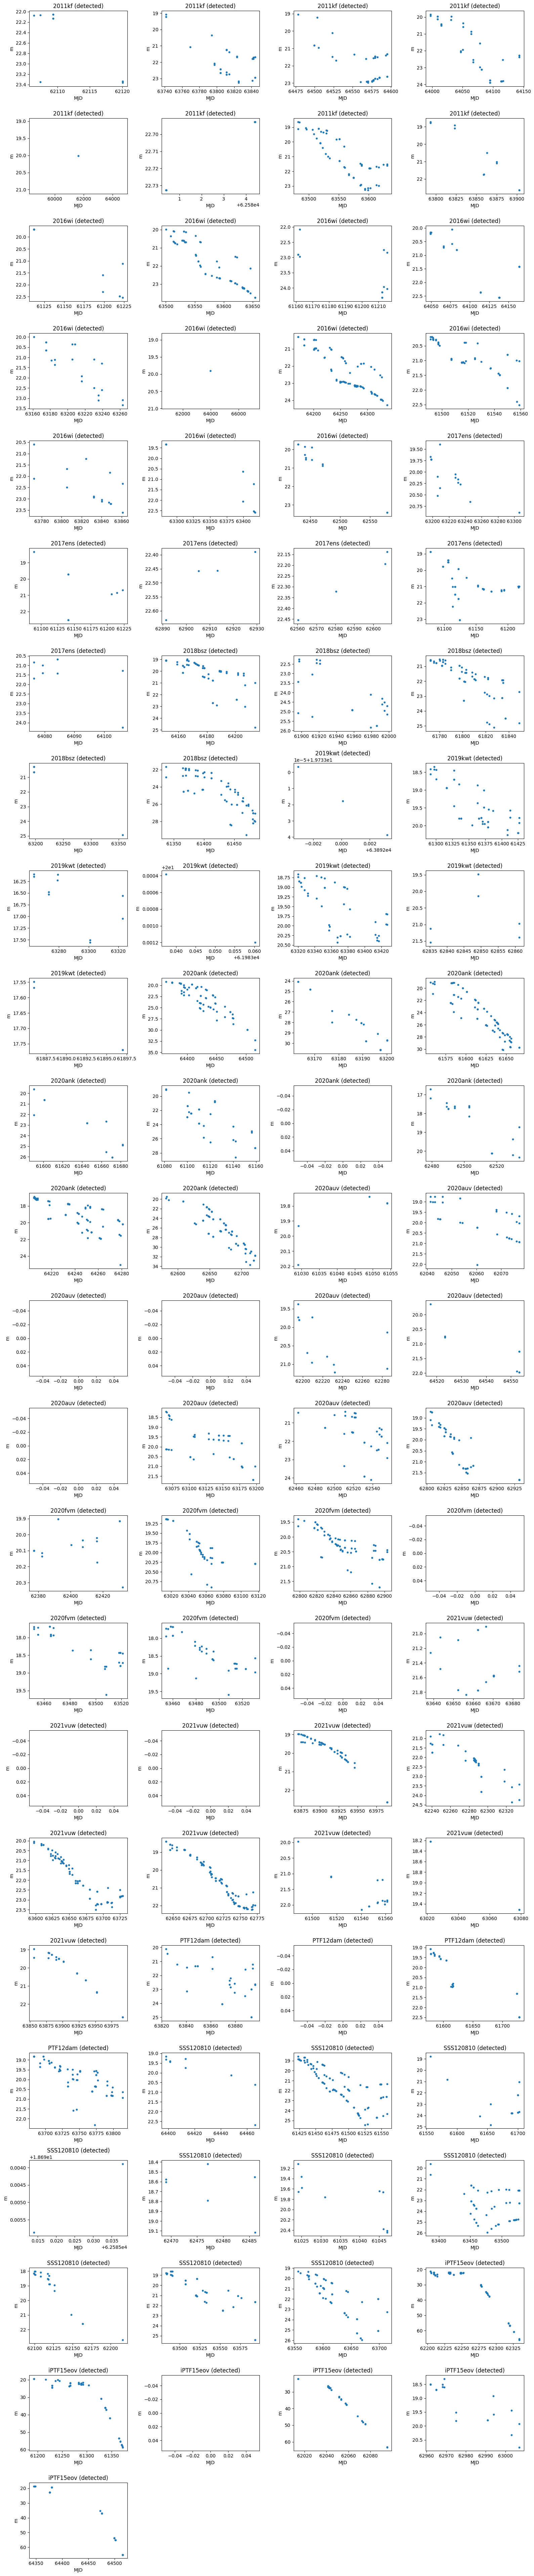

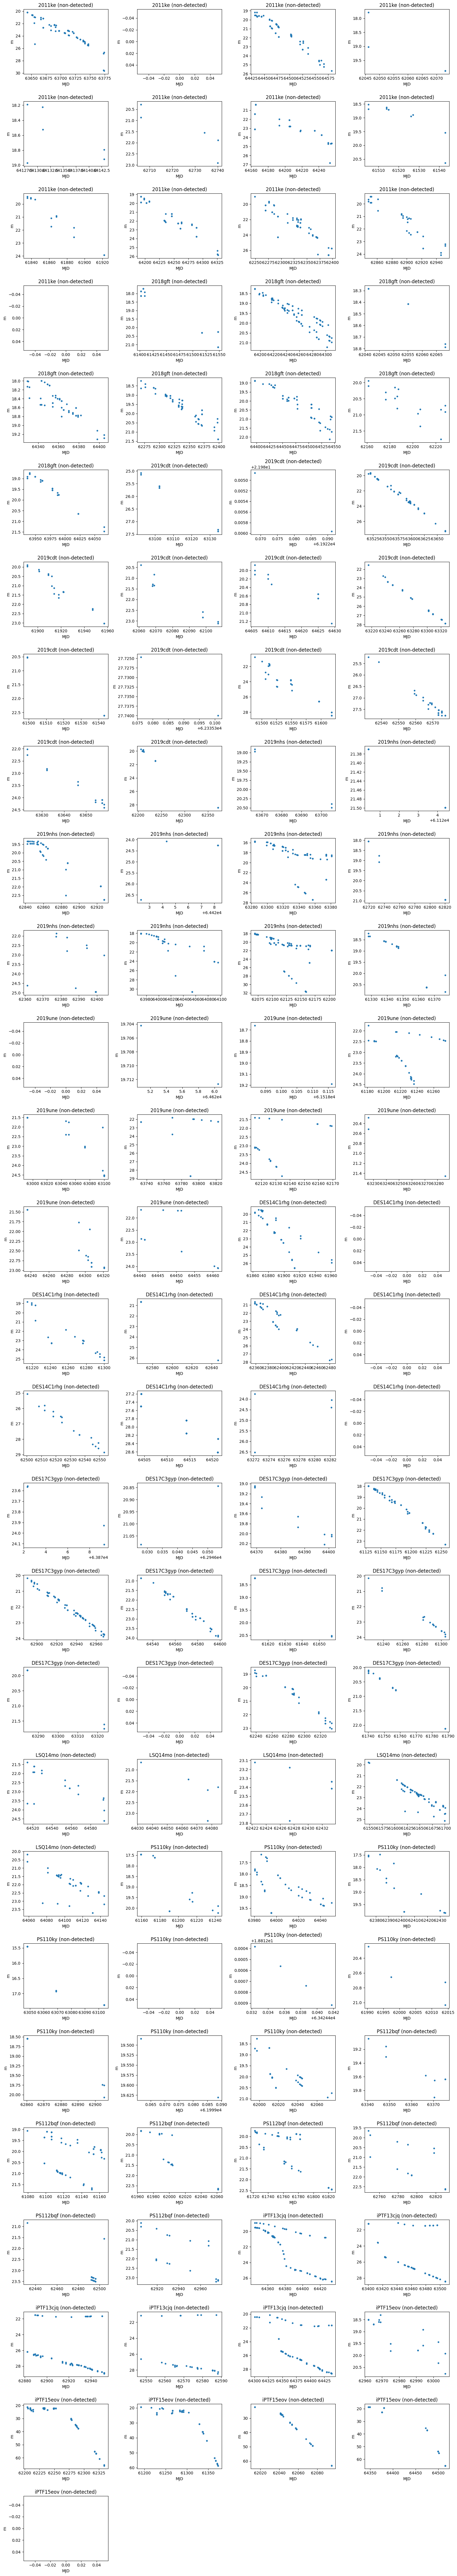

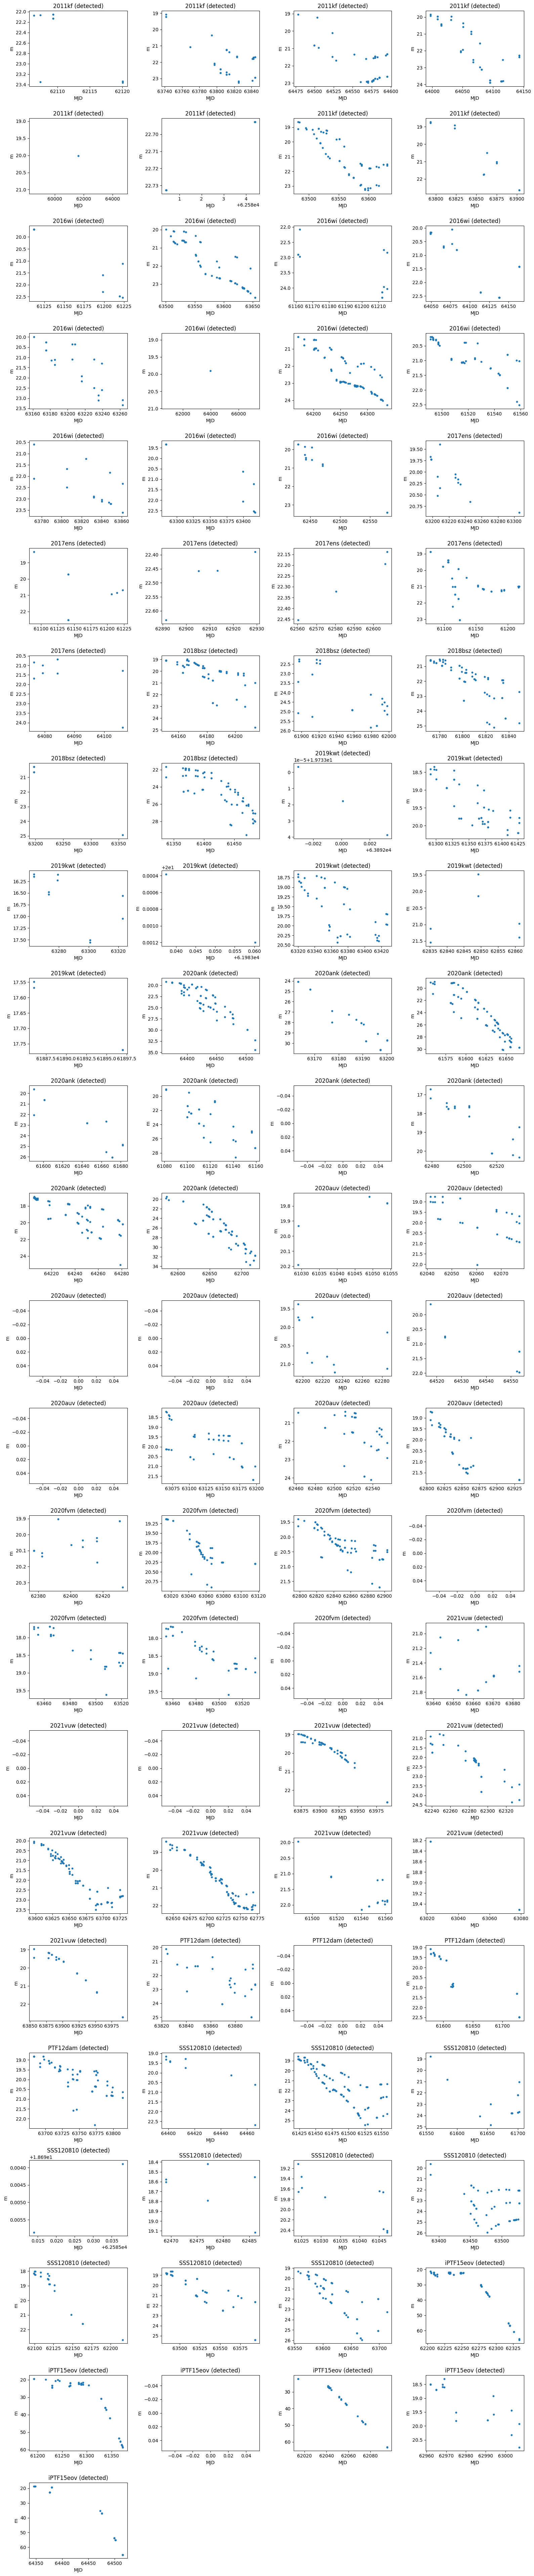

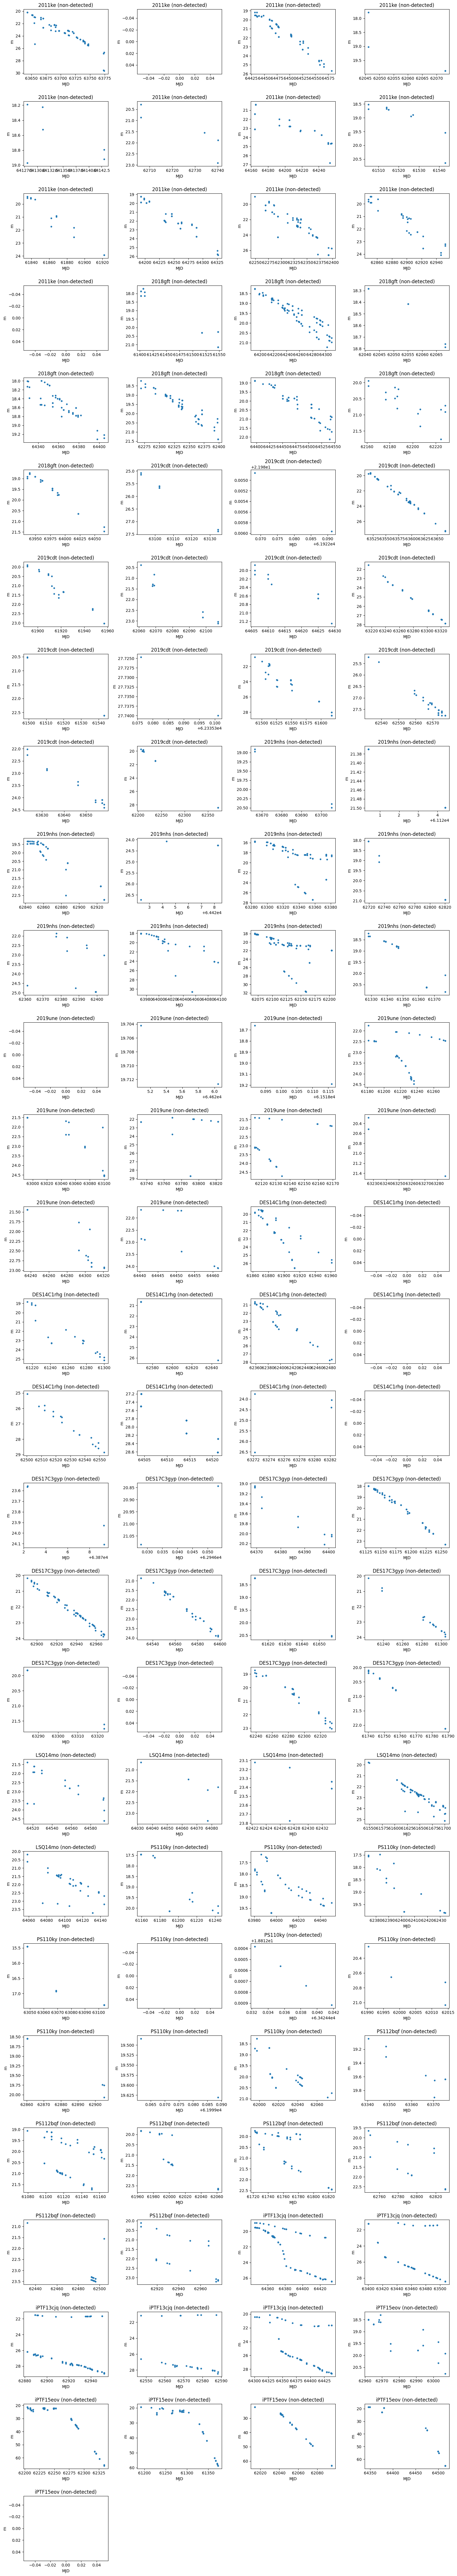

In [93]:

# If you have the LC object already (recommended):
# templates = slsn_metric.LC(load_from=templates_pkl)  # your current pattern
names = list(getattr(templates, "names", []))

# If you only have the pickle path:
# names = pickle.load(open(templates_pkl, "rb")).get("names", [])

# df_obs is what _build_detection_dataframe(...) returns inside runners.py
# It already has 'file_indx' and 'sid'
idx = pd.to_numeric(df_obs['file_indx'], errors='coerce')

def idx_to_name(i):
    if pd.isna(i): 
        return pd.NA
    i = int(i)
    return names[i] if 0 <= i < len(names) else pd.NA

df_obs['event_name'] = idx.apply(idx_to_name)

det_mask = df_obs['detected'].astype(bool)
detected_names     = df_obs.loc[det_mask, 'event_name'].dropna().unique().tolist()
nondetected_names  = df_obs.loc[~det_mask, 'event_name'].dropna().unique().tolist()

print(f"Detected: {len(detected_names)}  |  Non-detected: {len(nondetected_names)}")

def plot_event_obs(ax, row, title_suffix=""):
    # row is one df_obs record
    F = row.get('filter', []) or []
    M = row.get('mag_obs', []) or []
    T = row.get('mjd_obs', []) or []
    # simple scatter; you can color by filter if you wish
    ax.scatter(T, M, s=10)
    ax.invert_yaxis()
    ax.set_xlabel("MJD")
    ax.set_ylabel("m")
    name = row.get('event_name', 'unknown')
    ax.set_title(f"{name}{title_suffix}")

def mosaic(df, names_subset, ncols=4, title_suffix=""):
    sub = df[df['event_name'].isin(names_subset)].copy()
    sub = sub.sort_values('event_name').head(ncols * ((len(sub)+ncols-1)//ncols))
    n = len(sub)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3.2*nrows), squeeze=False)
    for ax, (_, row) in zip(axes.flat, sub.iterrows()):
        plot_event_obs(ax, row, title_suffix=title_suffix)
    # hide any extra axes
    for ax in axes.flat[n:]:
        ax.axis('off')
    plt.tight_layout()
    plt.show()
    return fig, axes

fig,_ = mosaic(df_obs, detected_names[:12], ncols=4, title_suffix=" (detected)")
fig,_ = mosaic(df_obs, nondetected_names[:12], ncols=4, title_suffix=" (non-detected)")



In [128]:
# ============================================================================
# Extract Categories CORRECTLY (Fixed)
# ============================================================================
# Re-run with proper storage
metrics_list = [
    SLSN_Detect_Metric(lc_model=templates, mjd0=mjd0, store_obs_mode="meta"),
    SLSN_CharacterizeMetric(lc_model=templates, mjd0=mjd0, store_obs_mode="meta"),
    SLSN_SpecTriggerMetric(lc_model=templates, mjd0=mjd0, store_obs_mode="meta")
]

# Then re-run your metric execution
# DETECTION (straightforward - df_detect has ALL events)
det_mask = df_detect['detected'].astype(bool)
detected_names = df_detect.loc[det_mask, 'event_name'].dropna().unique().tolist()
nondet_names = df_detect.loc[~det_mask, 'event_name'].dropna().unique().tolist()

print(f"\nDetection:")
print(f"  Total events in df_detect: {len(df_detect)}")
print(f"  Detected: {len(detected_names)}")
print(f"  Non-detected: {len(nondet_names)}")

# CHARACTERIZATION
# df_char only contains events that PASSED characterization
# So ALL events in df_char are characterized (if 'characterized' column exists and is True)

if 'characterized' in df_char.columns:
    # If column exists, filter by it
    char_mask = df_char['characterized'].fillna(False).astype(bool)
    characterized_names = df_char.loc[char_mask, 'event_name'].dropna().unique().tolist()
else:
    # If no column, assume all events in df_char passed
    characterized_names = df_char['event_name'].dropna().unique().tolist()

print(f"\nCharacterization:")
print(f"  Total events in df_char: {len(df_char)}")
print(f"  Characterized names extracted: {len(characterized_names)}")

# Non-characterized = detected but NOT in characterized set
characterized_set = set(characterized_names)
detected_set = set(detected_names)
nonchar_names = list(detected_set - characterized_set)

print(f"  Detected events: {len(detected_set)}")
print(f"  Characterized events: {len(characterized_set)}")
print(f"  Non-characterized (detected but not char): {len(nonchar_names)}")

if len(detected_names) > 0:
    print(f"  Characterization rate: {len(characterized_names)/len(detected_names)*100:.1f}% (of detected)")

# SPEC TRIGGER (same logic)
if 'spec_trigger' in df_spec.columns:
    spec_mask = df_spec['spec_trigger'].fillna(False).astype(bool)
    spec_names = df_spec.loc[spec_mask, 'event_name'].dropna().unique().tolist()
else:
    # If no column, assume all events in df_spec passed
    spec_names = df_spec['event_name'].dropna().unique().tolist()

print(f"\nSpec Trigger:")
print(f"  Total events in df_spec: {len(df_spec)}")
print(f"  Spec trigger names extracted: {len(spec_names)}")

# Non-triggers = detected but NOT in spec set
spec_set = set(spec_names)
nonspec_names = list(detected_set - spec_set)

print(f"  Detected events: {len(detected_set)}")
print(f"  Spec trigger events: {len(spec_set)}")
print(f"  Non-triggers (detected but not triggered): {len(nonspec_names)}")

if len(detected_names) > 0:
    print(f"  Trigger rate: {len(spec_names)/len(detected_names)*100:.1f}% (of detected)")

# ============================================================================
# Diagnostic: Check what's actually in the DataFrames
# ============================================================================

print("\n" + "="*70)
print("DIAGNOSTIC INFO")
print("="*70)
print(f"df_detect columns: {df_detect.columns.tolist()}")
print(f"df_char columns:   {df_char.columns.tolist()}")
print(f"df_spec columns:   {df_spec.columns.tolist()}")

# Check a few sample event names
print(f"\nSample detected names: {detected_names[:5]}")
print(f"Sample characterized names: {characterized_names[:5]}")
print(f"Sample spec trigger names: {spec_names[:5]}")
print(f"Sample non-characterized names: {nonchar_names[:5]}")
print("="*70 + "\n")

# ============================================================================
# Create Mosaics with Better Error Handling
# ============================================================================

def safe_mosaic_save(df, names_list, ncols, title_suffix, filepath):
    """Create and save mosaic, handling empty lists and None returns."""
    if len(names_list) == 0:
        print(f"  ⚠ Skipping {filepath.name}: no events in category")
        return
    
    print(f"  Creating {filepath.name} with {len(names_list)} events (showing {min(12, len(names_list))})...")
    
    try:
        fig, _ = mosaic(df, names_list[:12], ncols=ncols, title_suffix=title_suffix)
        
        if fig is None:
            print(f"  ⚠ Warning: mosaic returned None for {filepath.name}")
            return
        
        fig.savefig(filepath, dpi=150, bbox_inches='tight')
        plt.close(fig)
        print(f"  ✓ Saved {filepath.name}")
    except Exception as e:
        print(f"  ✗ Error creating {filepath.name}: {e}")

print("\nCreating mosaics...")
print("="*70)

# Detection mosaics (use df_detect - has all observations)
safe_mosaic_save(df_detect, detected_names, 4, " (detected)", 
                 output_dir / "01_detected_mosaic.png")
safe_mosaic_save(df_detect, nondet_names, 4, " (non-detected)", 
                 output_dir / "02_non_detected_mosaic.png")

# Characterization mosaics (use df_detect - has all observations)
safe_mosaic_save(df_detect, characterized_names, 4, " (characterized)", 
                 output_dir / "03_characterized_mosaic.png")
safe_mosaic_save(df_detect, nonchar_names, 4, " (detected but not characterized)", 
                 output_dir / "04_non_characterized_mosaic.png")

# Spec trigger mosaics (use df_detect - has all observations)
safe_mosaic_save(df_detect, spec_names, 4, " (spec trigger)", 
                 output_dir / "05_spec_trigger_mosaic.png")
safe_mosaic_save(df_detect, nonspec_names, 4, " (detected but not triggered)", 
                 output_dir / "06_non_spec_trigger_mosaic.png")

print("="*70)
print("\n✓ All mosaics created!")


Detection:
  Total events in df_detect: 1234
  Detected: 39
  Non-detected: 165

Characterization:
  Total events in df_char: 37
  Characterized names extracted: 24
  Detected events: 39
  Characterized events: 24
  Non-characterized (detected but not char): 15
  Characterization rate: 61.5% (of detected)

Spec Trigger:
  Total events in df_spec: 34
  Spec trigger names extracted: 21
  Detected events: 39
  Spec trigger events: 21
  Non-triggers (detected but not triggered): 18
  Trigger rate: 53.8% (of detected)

DIAGNOSTIC INFO
df_detect columns: ['sid', 'detected', 'file_indx', 'z', 'ra', 'dec', 'distance_Mpc', 'ebv', 'distance', 'distance_modulus', 'peak_time', 'n_observations_detected', 'n_filters_detected', 'eval_peak_mag', 'first_det_mjd', 'per_filter_min_mag', 'year', 'peak_mjd', 'event_name']
df_char columns:   ['sid', 'mjd_obs', 'mag_obs', 'snr_obs', 'filter', 'available_bands', 'characterized', 'n_epochs', 'n_filters_char', 'distance', 'distance_modulus', 'peak_time', 'file

In [126]:
# ============================================================================
# DIAGNOSTIC: Check DataFrame Contents
# ============================================================================

print("\n" + "="*70)
print("DATAFRAME CONTENT DIAGNOSTIC")
print("="*70)

# Check what columns exist
print(f"\ndf_detect columns:")
print(df_detect.columns.tolist())

# Check first row of detected event
if len(detected_names) > 0:
    first_detected = detected_names[0]
    row = df_detect[df_detect['event_name'] == first_detected].iloc[0]
    
    print(f"\nFirst detected event: {first_detected}")
    print(f"  sid: {row.get('sid', 'MISSING')}")
    print(f"  detected: {row.get('detected', 'MISSING')}")
    print(f"  mjd_obs type: {type(row.get('mjd_obs', 'MISSING'))}")
    print(f"  mjd_obs content: {row.get('mjd_obs', 'MISSING')}")
    print(f"  mag_obs type: {type(row.get('mag_obs', 'MISSING'))}")
    print(f"  mag_obs content: {row.get('mag_obs', 'MISSING')}")
    print(f"  filter type: {type(row.get('filter', 'MISSING'))}")
    print(f"  filter content: {row.get('filter', 'MISSING')}")
    
    # Check if arrays are empty
    mjd = row.get('mjd_obs', [])
    mag = row.get('mag_obs', [])
    filt = row.get('filter', [])
    
    if hasattr(mjd, '__len__'):
        print(f"\n  Length of mjd_obs: {len(mjd)}")
    if hasattr(mag, '__len__'):
        print(f"  Length of mag_obs: {len(mag)}")
    if hasattr(filt, '__len__'):
        print(f"  Length of filter: {len(filt)}")

print("="*70 + "\n")


DATAFRAME CONTENT DIAGNOSTIC

df_detect columns:
['sid', 'detected', 'file_indx', 'z', 'ra', 'dec', 'distance_Mpc', 'ebv', 'distance', 'distance_modulus', 'peak_time', 'n_observations_detected', 'n_filters_detected', 'eval_peak_mag', 'first_det_mjd', 'per_filter_min_mag', 'year', 'peak_mjd', 'event_name']

First detected event: 2017ens
  sid: 3
  detected: True
  mjd_obs type: <class 'str'>
  mjd_obs content: MISSING
  mag_obs type: <class 'str'>
  mag_obs content: MISSING
  filter type: <class 'str'>
  filter content: MISSING

  Length of mjd_obs: 0
  Length of mag_obs: 0
  Length of filter: 0



In [162]:
# ============================================================================
# Smart Mosaic Function (Uses Correct DataFrame)
# ============================================================================

def plot_event_obs_smart(ax, event_name, df_detect, df_char, df_spec, title_suffix=""):
    """
    Plot event using whichever DataFrame has the observation data.
    Tries: df_char → df_spec → df_detect
    """
    row = None
    source = None
    
    # Try to find the event in each DataFrame
    for df, name in [(df_char, 'char'), (df_spec, 'spec'), (df_detect, 'detect')]:
        matches = df[df['event_name'] == event_name]
        if len(matches) > 0:
            row = matches.iloc[0]
            # Check if this row has actual observations
            mjd = row.get('mjd_obs', [])
            if hasattr(mjd, '__len__') and len(mjd) > 0:
                source = name
                break
    
    if row is None or source is None:
        ax.text(0.5, 0.5, f'{event_name}\nNo observations found', 
               ha='center', va='center', transform=ax.transAxes)
        ax.set_xlabel("MJD", fontsize=8)
        ax.set_ylabel("Apparent Mag", fontsize=8)
        return
    
    # Extract observations
    F = row.get('filter', []) or []
    M = row.get('mag_obs', []) or []
    T = row.get('mjd_obs', []) or []
    
    # Convert to arrays if needed
    F = np.asarray(F)
    M = np.asarray(M, dtype=float)
    T = np.asarray(T, dtype=float)
    
    # Filter out invalid values
    valid = np.isfinite(M) & np.isfinite(T) & (M < 90)
    F, M, T = F[valid], M[valid], T[valid]
    
    if len(T) == 0:
        ax.text(0.5, 0.5, f'{event_name}\nNo valid observations', 
               ha='center', va='center', transform=ax.transAxes)
        ax.set_xlabel("MJD", fontsize=8)
        ax.set_ylabel("Apparent Mag", fontsize=8)
        return
    
    # Plot with colors
    colors = {'u': 'purple', 'g': 'blue', 'r': 'green', 
             'i': 'orange', 'z': 'red', 'y': 'darkred'}
    
    if len(F) > 0 and len(F) == len(M):
        for filt in np.unique(F):
            mask = F == filt
            if np.any(mask):
                ax.scatter(T[mask], M[mask], s=15, alpha=0.7, 
                          color=colors.get(filt, 'gray'), label=filt)
        if len(np.unique(F)) <= 4:
            ax.legend(fontsize=6, loc='best', framealpha=0.7)
    else:
        ax.scatter(T, M, s=15, alpha=0.7, color='gray')
    
    ax.invert_yaxis()
    ax.set_xlabel("MJD", fontsize=8)
    ax.set_ylabel("Apparent Mag", fontsize=8)
    ax.set_title(f"{event_name}{title_suffix} [{source}]", fontsize=9)
    ax.grid(alpha=0.3)


def mosaic_smart(names_subset, df_detect, df_char, df_spec, 
                ncols=4, title_suffix="", suptitle=None):
    """Create mosaic using smart DataFrame selection."""
    n = min(len(names_subset), ncols * 3)
    names_to_plot = names_subset[:n]
    
    if n == 0:
        print(f"Warning: No events to plot")
        return None, None
    
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows), squeeze=False)
    
    for ax, name in zip(axes.flat, names_to_plot):
        plot_event_obs_smart(ax, name, df_detect, df_char, df_spec, title_suffix)
    
    for ax in axes.flat[n:]:
        ax.axis('off')
    
    if suptitle:
        fig.suptitle(suptitle, fontsize=14, y=0.995, fontweight='bold')
    
    plt.tight_layout(rect=[0, 0, 1, 0.99])
    return fig, axes


# ============================================================================
# Create Mosaics with Smart Function
# ============================================================================

def safe_mosaic_save_smart(names_list, df_detect, df_char, df_spec, 
                          ncols, title_suffix, filepath, suptitle=None):
    """Create and save mosaic using smart DataFrame selection."""
    if len(names_list) == 0:
        print(f"  ⚠ Skipping {filepath.name}: no events in category")
        return
    
    print(f"  Creating {filepath.name} with {len(names_list)} events...")
    
    try:
        fig, _ = mosaic_smart(names_list, df_detect, df_char, df_spec,
                            ncols=ncols, title_suffix=title_suffix, 
                            suptitle=suptitle)
        
        if fig is None:
            print(f"  ⚠ Warning: mosaic returned None for {filepath.name}")
            return
        
        fig.savefig(filepath, dpi=150, bbox_inches='tight')
        plt.close(fig)
        print(f"  ✓ Saved {filepath.name}")
    except Exception as e:
        print(f"  ✗ Error creating {filepath.name}: {e}")
        import traceback
        traceback.print_exc()


print("\nCreating mosaics with smart DataFrame selection...")
print("="*70)

# Detection mosaics
safe_mosaic_save_smart(detected_names, df_detect, df_char, df_spec, 4, 
                      "", output_dir / "01_detected_mosaic.png",
                      suptitle="Detected SLSNe")

safe_mosaic_save_smart(nondet_names, df_detect, df_char, df_spec, 4,
                      "", output_dir / "02_non_detected_mosaic.png",
                      suptitle="Non-Detected SLSNe")

# Characterization mosaics
safe_mosaic_save_smart(characterized_names, df_detect, df_char, df_spec, 4,
                      "", output_dir / "03_characterized_mosaic.png",
                      suptitle="Characterized SLSNe")

safe_mosaic_save_smart(nonchar_names, df_detect, df_char, df_spec, 4,
                      "", output_dir / "04_non_characterized_mosaic.png",
                      suptitle="Non-Characterized (Detected)")

# Spec trigger mosaics
safe_mosaic_save_smart(spec_names, df_detect, df_char, df_spec, 4,
                      "", output_dir / "05_spec_trigger_mosaic.png",
                      suptitle="Spectroscopic Triggers")

safe_mosaic_save_smart(nonspec_names, df_detect, df_char, df_spec, 4,
                      "", output_dir / "06_non_spec_trigger_mosaic.png",
                      suptitle="Non-Triggers (Detected)")

print("="*70)
print("\n✓ All mosaics created with smart DataFrame selection!")


Creating mosaics with smart DataFrame selection...
  Creating 01_detected_mosaic.png with 39 events...
  ✓ Saved 01_detected_mosaic.png
  Creating 02_non_detected_mosaic.png with 165 events...
  ✓ Saved 02_non_detected_mosaic.png
  Creating 03_characterized_mosaic.png with 24 events...
  ✓ Saved 03_characterized_mosaic.png
  Creating 04_non_characterized_mosaic.png with 15 events...
  ✓ Saved 04_non_characterized_mosaic.png
  Creating 05_spec_trigger_mosaic.png with 21 events...
  ✓ Saved 05_spec_trigger_mosaic.png
  Creating 06_non_spec_trigger_mosaic.png with 18 events...
  ✓ Saved 06_non_spec_trigger_mosaic.png

✓ All mosaics created with smart DataFrame selection!


In [167]:
#============================================================================
# SOLUTION: Reconstruct Light Curves from Templates + Population
# ============================================================================

def reconstruct_observations(event_name, df_detect, slicer, templates, mjd0):
    """
    Reconstruct apparent magnitude light curve from template + population params.
    
    This works even if obs_records weren't stored, by using:
    - Template absolute magnitudes
    - Population redshift, distance, extinction
    - OpSim observation times (if available, else use template phases)
    """
    # Find event in df_detect
    matches = df_detect[df_detect['event_name'] == event_name]
    if len(matches) == 0:
        return None, None, None, "not_in_detect"
    
    row = matches.iloc[0]
    sid = int(row['sid'])
    
    # Get population parameters
    try:
        # Find index in slicer
        sid_arr = np.asarray(slicer.slice_points['sid'], dtype=int)
        idx = np.where(sid_arr == sid)[0]
        if len(idx) == 0:
            return None, None, None, "sid_not_in_slicer"
        idx = int(idx[0])
        
        z = float(slicer.slice_points['z'][idx])
        dm = float(slicer.slice_points['distance_modulus'][idx])
        peak_time = float(slicer.slice_points['peak_time'][idx])
        file_indx = int(slicer.slice_points['file_indx'][idx])
        ebv = float(slicer.slice_points['ebv'][idx])
        
    except Exception as e:
        return None, None, None, f"param_error: {e}"
    
    # Get template
    if file_indx < 0 or file_indx >= len(templates.data):
        return None, None, None, "bad_template_idx"
    
    template = templates.data[file_indx]
    
    # Get available bands
    bands = [b for b in template.keys() 
             if isinstance(template[b], dict) and 'ph' in template[b]]
    
    if len(bands) == 0:
        return None, None, None, "no_bands_in_template"
    
    # Generate time grid (±100 days around peak in observed frame)
    t_obs = np.linspace(-50, 150, 200) + mjd0 + peak_time
    
    # Calculate rest-frame phases
    phase_rest = (t_obs - mjd0 - peak_time) / (1.0 + z)
    
    # Collect all observations
    all_mjd = []
    all_mag = []
    all_filt = []
    
    # Get extinction per filter
    from rubin_sim.phot_utils import DustValues
    ax1 = DustValues().ax1
    
    for band in ['u', 'g', 'r', 'i', 'z', 'y']:
        # Check if template has this band or a similar one
        template_band = band
        if band not in template:
            # Try catalog equivalents
            mapping = {'g': 'g', 'r': 'r', 'i': 'i', 'z': 'z'}
            if band in mapping and mapping[band] in template:
                template_band = mapping[band]
            else:
                continue
        
        # Interpolate absolute magnitudes
        try:
            M_abs = templates.interp(phase_rest, template_band, file_indx)
        except:
            continue
        
        # Apply distance modulus and extinction
        A_band = ax1.get(band, 0.0) * ebv
        m_app = M_abs + dm + A_band
        
        # Keep only finite values
        valid = np.isfinite(m_app) & (m_app < 30)
        
        if np.any(valid):
            all_mjd.extend(t_obs[valid].tolist())
            all_mag.extend(m_app[valid].tolist())
            all_filt.extend([band] * int(np.sum(valid)))
    
    if len(all_mjd) == 0:
        return None, None, None, "no_valid_points"
    
    return np.array(all_mjd), np.array(all_mag), np.array(all_filt), "success"


def plot_event_reconstructed(ax, event_name, df_detect, slicer, templates, 
                             mjd0, title_suffix=""):
    """
    Plot event using reconstructed light curve from templates.
    """
    T, M, F, status = reconstruct_observations(event_name, df_detect, slicer, 
                                               templates, mjd0)
    
    if status != "success":
        ax.text(0.5, 0.5, f'{event_name}\n{status}', 
               ha='center', va='center', transform=ax.transAxes, fontsize=8)
        ax.set_xlabel("MJD", fontsize=8)
        ax.set_ylabel("Apparent Mag", fontsize=8)
        return
    
    # Plot with colors
    colors = {'u': 'purple', 'g': 'blue', 'r': 'green', 
             'i': 'orange', 'z': 'red', 'y': 'darkred'}
    
    for filt in np.unique(F):
        mask = F == filt
        ax.scatter(T[mask], M[mask], s=8, alpha=0.6, 
                  color=colors.get(filt, 'gray'), label=filt)
    
    ax.invert_yaxis()
    ax.set_xlabel("MJD", fontsize=8)
    ax.set_ylabel("Apparent Mag", fontsize=8)
    ax.set_title(f"{event_name}{title_suffix} [reconstructed]", fontsize=9)
    ax.grid(alpha=0.3)
    
    if len(np.unique(F)) <= 4:
        ax.legend(fontsize=6, loc='best', framealpha=0.7)


def mosaic_reconstructed(names_subset, df_detect, slicer, templates, mjd0,
                        ncols=4, title_suffix="", suptitle=None):
    """Create mosaic using reconstructed light curves."""
    n = min(len(names_subset), ncols * 3)
    names_to_plot = names_subset[:n]
    
    if n == 0:
        return None, None
    
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows), squeeze=False)
    
    for ax, name in zip(axes.flat, names_to_plot):
        plot_event_reconstructed(ax, name, df_detect, slicer, templates, 
                                mjd0, title_suffix)
    
    for ax in axes.flat[n:]:
        ax.axis('off')
    
    if suptitle:
        fig.suptitle(suptitle, fontsize=14, y=0.995, fontweight='bold')
    
    plt.tight_layout(rect=[0, 0, 1, 0.99])
    return fig, axes


# ============================================================================
# Create Mosaics with Reconstruction
# ============================================================================

print("\nCreating mosaics with RECONSTRUCTED light curves...")
print("="*70)

def safe_mosaic_save_reconstructed(names_list, df_detect, slicer, templates, 
                                   mjd0, ncols, filepath, suptitle=None):
    """Save mosaic using reconstructed observations."""
    if len(names_list) == 0:
        print(f"  ⚠ Skipping {filepath.name}: no events")
        return
    
    print(f"  Creating {filepath.name} with {len(names_list)} events...")
    
    try:
        fig, _ = mosaic_reconstructed(names_list, df_detect, slicer, templates, 
                                     mjd0, ncols=ncols, suptitle=suptitle)
        
        if fig is None:
            print(f"  ⚠ Warning: mosaic returned None")
            return
        
        fig.savefig(filepath, dpi=150, bbox_inches='tight')
        plt.close(fig)
        print(f"  ✓ Saved {filepath.name}")
    except Exception as e:
        print(f"  ✗ Error: {e}")
        import traceback
        traceback.print_exc()


# Detection mosaics
safe_mosaic_save_reconstructed(
    detected_names, df_detect, slicer, templates, mjd0, 4,
    output_dir / "01_detected_reconstructed.png",
    suptitle="Detected SLSNe (Reconstructed Light Curves)"
)

safe_mosaic_save_reconstructed(
    nondet_names, df_detect, slicer, templates, mjd0, 4,
    output_dir / "02_non_detected_reconstructed.png",
    suptitle="Non-Detected SLSNe (Reconstructed)"
)

# Characterization mosaics
safe_mosaic_save_reconstructed(
    characterized_names, df_detect, slicer, templates, mjd0, 4,
    output_dir / "03_characterized_reconstructed.png",
    suptitle="Characterized SLSNe (Reconstructed)"
)

safe_mosaic_save_reconstructed(
    nonchar_names, df_detect, slicer, templates, mjd0, 4,
    output_dir / "04_non_characterized_reconstructed.png",
    suptitle="Detected but Not Characterized (Reconstructed)"
)

# Spec trigger mosaics
safe_mosaic_save_reconstructed(
    spec_names, df_detect, slicer, templates, mjd0, 4,
    output_dir / "05_spec_trigger_reconstructed.png",
    suptitle="Spectroscopic Triggers (Reconstructed)"
)

safe_mosaic_save_reconstructed(
    nonspec_names, df_detect, slicer, templates, mjd0, 4,
    output_dir / "06_non_spec_trigger_reconstructed.png",
    suptitle="Non-Triggers (Reconstructed)"
)

print("="*70)
print("\n✓ All mosaics created with RECONSTRUCTED observations!")
print("\nNote: These show the FULL template light curves, not just")
print("      the observations that Rubin would have actually made.")
print("      For observed-only points, use obs_records from metrics.")


Creating mosaics with RECONSTRUCTED light curves...
  Creating 01_detected_reconstructed.png with 39 events...
  ✓ Saved 01_detected_reconstructed.png
  Creating 02_non_detected_reconstructed.png with 165 events...
  ✓ Saved 02_non_detected_reconstructed.png
  Creating 03_characterized_reconstructed.png with 24 events...
  ✓ Saved 03_characterized_reconstructed.png
  Creating 04_non_characterized_reconstructed.png with 15 events...
  ✓ Saved 04_non_characterized_reconstructed.png
  Creating 05_spec_trigger_reconstructed.png with 21 events...
  ✓ Saved 05_spec_trigger_reconstructed.png
  Creating 06_non_spec_trigger_reconstructed.png with 18 events...
  ✓ Saved 06_non_spec_trigger_reconstructed.png

✓ All mosaics created with RECONSTRUCTED observations!

Note: These show the FULL template light curves, not just
      the observations that Rubin would have actually made.
      For observed-only points, use obs_records from metrics.


In [261]:
# sky_animation.py
# Animate Rubin's sky coverage and detection accumulation.
# Save as MP4 (ffmpeg) or GIF (pillow). Pure matplotlib; no external services.
import matplotlib.patheffects as pe
# add at the top (or replace previous patheffects import)
from matplotlib import patheffects as pe
from __future__ import annotations
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter, PillowWriter
from typing import Optional, Sequence, Dict
def _as_scalar_label(v):
    """Return a hashable scalar label from possibly iterable values.
    - If v is list/tuple/ndarray/set: use first element if non-empty, else None.
    - Otherwise return v unchanged.
    """
    import numpy as np
    if isinstance(v, (list, tuple, set, np.ndarray)):
        v = list(v)
        return v[0] if len(v) else None
    return v

def _infer_units_deg(ra_series, dec_series):
    """
    Return (ra_deg, dec_deg, info_str).
    If inputs appear to be in radians, convert to degrees.
    Heuristics:
      - If max|ra| <= ~2π+ε and max|dec| <= ~π/2+ε -> radians
      - Else assume degrees
    """
    import numpy as np
    ra = pd.to_numeric(ra_series, errors="coerce").values.astype(float)
    dec = pd.to_numeric(dec_series, errors="coerce").values.astype(float)

    ra_finite = np.isfinite(ra)
    dec_finite = np.isfinite(dec)
    if not ra_finite.any() or not dec_finite.any():
        return ra, dec, "units=unknown (passed through)"

    ra_max = np.nanmax(np.abs(ra[ra_finite]))
    dec_max = np.nanmax(np.abs(dec[dec_finite]))
    eps = 1e-3
    is_rad = (ra_max <= (2*np.pi + eps)) and (dec_max <= (np.pi/2 + eps))

    if is_rad:
        return np.degrees(ra), np.degrees(dec), "units: radians→degrees"
    else:
        return ra, dec, "units: degrees"


# -----------------------------
# Utility transforms
# -----------------------------
def _wrap_ra_deg_to_mollweide(ra_deg: np.ndarray) -> np.ndarray:
    """Convert RA [deg] to Mollweide x [rad], wrapping to [-pi, pi] and flipping handedness.
    Mollweide expects longitudes increasing to the left; astronomy RA increases to the east.
    We map x = - (RA - 180°) to center 180° at the middle and flip sign."""
    x = np.radians(180.0 - (ra_deg % 360.0))
    x = (x + np.pi) % (2.0 * np.pi) - np.pi  # ensure in [-pi, pi)
    return x

def _dec_deg_to_rad(dec_deg: np.ndarray) -> np.ndarray:
    return np.radians(np.clip(dec_deg, -90.0, 90.0))

# -----------------------------
# Core animator
# -----------------------------
def make_detection_animation(
    df: pd.DataFrame,
    output_path: str,
    *,
    time_label: str = "mjd",      # {"mjd","since_start","iso","frame"}
    mjd0: float | None = None,    # if None, inferred from the minimum time
    ra_col: str = "ra",
    dec_col: str = "dec",
    time_col: str = "mjd",
    detected_col: Optional[str] = "detected",
    filter_col: Optional[str] = "filter",
    event_id_col: Optional[str] = "event_name",
    mode: str = "scan",
    fps: int = 15,
    dpi: int = 150,
    # --- contrast & style knobs ---
    s_visit: float = 1.6,                    # smaller, many points
    s_detect: float = 18.0,                  # larger, salient
    visits_color: str = "#8ea6ff",           # cool, dim blue
    visits_alpha: float = 0.18,
    visits_zorder: int = 1,
    detect_face: str = "#ffd34d",            # bright gold
    detect_edge: str = "#000000",            # thin black rim
    detect_alpha: float = 0.95,
    detect_zorder: int = 3,
    use_glow: bool = True,                   # halo around detections
    glow_size: float = 34.0,                 # > s_detect
    glow_alpha: float = 0.28,
    glow_color: str = "#fff2b3",             # soft light gold
    cmap_filters: Optional[Dict[str,str]] = None,
    t_stride: int = 1,
    max_frames: Optional[int] = None,
    bg_color: str = "#0b0b0f",               # near-black
    coast_alpha: float = 0.06,
    title_prefix: str = "Rubin Sky Scan",
    annotate_counts: bool = True,
    show_progress: bool = True,
):

    """
    Parameters
    ----------
    df : DataFrame
        Either per-visit pointings (ra/dec/time/filter) OR per-event detections with 'detected' flag and optional event ids.
        If both are present, the animation will show cumulative visits and highlight detected events distinctly.
    output_path : str
        Path ending in .mp4 or .gif.
    mode : {"scan","random"}
        "scan" reveals cumulative coverage in chronological order (sorted by `time_col`).
        "random" reveals positions in random batches (ignores actual times), useful for 'random sky plotting'.
    """
    assert output_path.lower().endswith((".mp4", ".gif")), "output_path must end with .mp4 or .gif"

    # Defensive copies + type coercions
    work = df.copy()
    if time_col in work.columns:
        # robust to mjd strings
        work[time_col] = pd.to_numeric(work[time_col], errors="coerce")
    else:
        # fabricate a pseudo-time if absent
        work[time_col] = np.arange(len(work), dtype=float)

    # Normalize detection flag
    if detected_col and detected_col in work.columns:
        det = work[detected_col].values
        if work[detected_col].dtype != bool:
            det = (pd.to_numeric(work[detected_col], errors="coerce").fillna(0).astype(int) > 0).values
        work["_detected_bool"] = det
    else:
        work["_detected_bool"] = False

    # Map filters to colors (optional)

    if filter_col and filter_col in work.columns and cmap_filters is not None:
        work["_filter_scalar"] = work[filter_col].apply(_as_scalar_label)
        filters = sorted([f for f in work["_filter_scalar"].dropna().unique()])
        palette = {f: cmap_filters.get(f, visits_color) for f in filters}
        work["_color"] = work["_filter_scalar"].map(palette).fillna(visits_color)
    else:
        work["_color"] = visits_color


    # Project to Mollweide
    # Auto-detect & normalize to degrees first
    ra_deg, dec_deg, unit_info = _infer_units_deg(work[ra_col], work[dec_col])
    if show_progress:
        print(f"[sky_animation] {unit_info}  (RA range: {np.nanmin(ra_deg):.3f}–{np.nanmax(ra_deg):.3f} deg)")
    
    X = _wrap_ra_deg_to_mollweide(ra_deg)
    Y = _dec_deg_to_rad(dec_deg)

    work["_x"], work["_y"] = X, Y

    # Determine time bins / frames
    if mode == "scan":
        work_sorted = work.sort_values(time_col)
        unique_t = np.unique(work_sorted[time_col].values[~np.isnan(work_sorted[time_col].values)])
    else:  # random
        work_sorted = work.sample(frac=1.0, random_state=42).reset_index(drop=True)
        # create pseudo-time steps as integer bins
        n = len(work_sorted)
        # choose ~200 batches or len/1000 points per batch, whichever smaller
        batches = max(20, min(200, n // 1000 if n > 0 else 20))
        unique_t = np.arange(batches, dtype=float)
        # assign each row to a random batch
        work_sorted["_rand_batch"] = np.random.RandomState(123).randint(0, batches, size=n)
        work_sorted[time_col] = work_sorted["_rand_batch"].astype(float)

    # after computing work_sorted and unique_t
    t0 = (mjd0 if mjd0 is not None else np.nanmin(unique_t)) if len(unique_t) else None

    # stride frames for performance
    unique_t = unique_t[::max(1, t_stride)]
    if max_frames is not None and len(unique_t) > max_frames:
        unique_t = unique_t[:max_frames]

    # Precompute cumulative masks per frame index for speed
    # Build indices into work_sorted for each frame
    time_values = work_sorted[time_col].values
    order_idx = np.arange(len(work_sorted))

    frame_indices: Sequence[np.ndarray] = []
    for t in unique_t:
        idx = order_idx[time_values <= t]
        frame_indices.append(idx)

    # Identify if the time axis is a synthetic frame
    is_frame_time = (time_col.lower() == "frame")
    
    # If animating with a frame index, prepare a per-frame MJD label
    mjd_for_frame = None
    if is_frame_time:
        if "mjd" in work_sorted.columns:
            # Choose a representative MJD per frame (max within each bin reads nicely)
            mjd_for_frame = (
                work_sorted.groupby(time_col)["mjd"]
                .max()
                .reindex(sorted(work_sorted[time_col].unique()))
                .to_numpy()
            )
        else:
            print("[sky_animation] Warning: time_col is 'frame' but no 'mjd' column found for labeling.")

    # Reference start for labeling
    if is_frame_time and mjd_for_frame is not None:
        t0 = (mjd0 if mjd0 is not None else float(mjd_for_frame[0]))
    else:
        t0 = (mjd0 if mjd0 is not None else (np.nanmin(unique_t) if len(unique_t) else None))


    # --- figure & axes ---
    plt.close("all")
    fig = plt.figure(figsize=(10, 5), facecolor=bg_color)
    ax = plt.axes(projection="mollweide")
    ax.set_facecolor(bg_color)
    ax.grid(True, alpha=coast_alpha, color="white", linestyle=":", linewidth=0.5, zorder=0)

    tick_col = "#B8B8BF"  # light gray that reads on dark bg
    ax.tick_params(axis="both", which="both", colors=tick_col, labelsize=9)
    
    # (Optional) also recolor existing tick lines and labels explicitly
    for line in ax.xaxis.get_ticklines() + ax.yaxis.get_ticklines():
        line.set_color(tick_col)
    for lab in ax.get_xticklabels() + ax.get_yticklabels():
        lab.set_color(tick_col)
    
    # --- layers ---
    # visits: many faint points, drawn first
    scat_visits = ax.scatter([], [], s=s_visit, alpha=visits_alpha, zorder=visits_zorder)
    
    # optional glow under detections (drawn larger, translucent)
    scat_glow = ax.scatter([], [], s=glow_size, alpha=glow_alpha, zorder=detect_zorder-1) if use_glow else None
    
    # sharp detection dots with thin dark rim (drawn last)
    scat_detect = ax.scatter([], [], s=s_detect, alpha=detect_alpha, edgecolor=detect_edge,
                             linewidths=0.6, zorder=detect_zorder)
    
    title = ax.set_title(f"{title_prefix}", color="white", fontsize=12, pad=12)
    txt_counts = ax.text(0.02, 0.02, "", transform=ax.transAxes, color="white",
                         fontsize=10, ha="left", va="bottom")
    
    # data arrays
    xs = work_sorted["_x"].values
    ys = work_sorted["_y"].values
    cols = work_sorted["_color"].values
    detmask = work_sorted["_detected_bool"].values
    
    # optional event ids
    if event_id_col and event_id_col in work_sorted.columns:
        work_sorted["_event_id_scalar"] = work_sorted[event_id_col].apply(_as_scalar_label)
        event_ids = work_sorted["_event_id_scalar"].values
    else:
        event_ids = None
    
    # path effects for a subtle glow edge refinement (optional)
    # For text or markers: outline with black, then draw normal fill
    pe_detect = [pe.withStroke(linewidth=1.2, foreground="black")]

    def _update(frame_i: int):
        idx = frame_indices[frame_i]
        xv, yv, cv = xs[idx], ys[idx], cols[idx]
    
        # visits layer (cumulative)
        scat_visits.set_offsets(np.c_[xv, yv])
        scat_visits.set_facecolors(cv)
        scat_visits.set_edgecolors("none")
    
        # detections subset so far
        dmask = detmask[idx]
        xd, yd = xv[dmask], yv[dmask]
    
        if use_glow:
            scat_glow.set_offsets(np.c_[xd, yd])
            scat_glow.set_facecolors(glow_color)
            scat_glow.set_edgecolors("none")
            scat_glow.set_alpha(glow_alpha)
    
        scat_detect.set_offsets(np.c_[xd, yd])
        scat_detect.set_path_effects(pe_detect)
        scat_detect.set_facecolors(detect_face)
        # keep a crisp rim for visibility on both dark and crowded regions
        scat_detect.set_edgecolors(detect_edge)
        scat_detect.set_alpha(detect_alpha)
    
        # optional path effects (comment out if slow)
        # scat_detect.set_path_effects(pe_detect)
    
        # title/time annotation
        t_val = unique_t[frame_i]
        if mode == "scan":
            raw_t = unique_t[frame_i]
            label_mjd = (
                mjd_for_frame[int(raw_t)] if (is_frame_time and mjd_for_frame is not None) else raw_t
            )
            if time_label == "mjd":
                title.set_text(f"{title_prefix} — MJD ≤ {label_mjd:.3f}")
            elif time_label == "since_start" and t0 is not None:
                dt = label_mjd - t0
                title.set_text(f"{title_prefix} — Δt ≤ {dt:.2f} d since MJD {t0:.1f}")
            elif time_label == "iso":
                try:
                    from astropy.time import Time
                    title.set_text(f"{title_prefix} — ≤ {Time(t_val, format='mjd').isot}")
                except Exception:
                    title.set_text(f"{title_prefix} — MJD ≤ {t_val:.3f}")
            else:  # "frame" or fallback
                title.set_text(f"{title_prefix} — t ≤ {t_val:.3f} ({time_col})")
        else:
            title.set_text(f"{title_prefix} — batch ≤ {int(t_val)} (random reveal)")

        return scat_visits, scat_glow if use_glow else scat_detect, scat_detect, title, txt_counts


    anim = FuncAnimation(
        fig,
        _update,
        frames=len(frame_indices),
        interval=1000 / fps,
        blit=False,
        repeat=False,
    )

    # Choose writer
    ext = os.path.splitext(output_path)[-1].lower()
    os.makedirs(os.path.dirname(os.path.abspath(output_path)), exist_ok=True)
    metadata = dict(artist="Rubin Fast Transient Metrics", title=title_prefix)

    if ext == ".mp4":
        try:
            writer = FFMpegWriter(fps=fps, metadata=metadata, codec="h264", bitrate=-1)
        except Exception as e:
            raise RuntimeError(
                "FFmpeg is required for MP4 output. Install ffmpeg (e.g., via Homebrew: `brew install ffmpeg`)."
            ) from e
        anim.save(output_path, writer=writer, dpi=dpi, savefig_kwargs={"facecolor": bg_color})
    else:
        # GIF path
        try:
            writer = PillowWriter(fps=fps, metadata=metadata)
        except Exception as e:
            raise RuntimeError("Pillow is required for GIF output. Install pillow (`pip install pillow`).") from e
        anim.save(output_path, writer=writer, dpi=dpi, savefig_kwargs={"facecolor": bg_color})

    if show_progress:
        print(f"[sky_animation] Saved animation to: {output_path}")




In [177]:
# -----------------------------
# Example usage (safe to delete)
# -----------------------------
if __name__ == "__main__":
    # Minimal synthetic demo (random pointings + random detections)
    rng = np.random.default_rng(123)
    n = 8000
    demo = pd.DataFrame({
        "ra": rng.uniform(0, 360, n),
        "dec": np.degrees(np.arcsin(rng.uniform(-1, 1, n))),  # uniform on sphere
        "mjd": np.sort(rng.uniform(60000, 60010, n)),
        "filter": rng.choice(list("griz"), n),
    })
    # Simulate ~5% detected events sprinkled through time
    demo["detected"] = (rng.random(n) < 0.05).astype(int)
    # Optional: label events (for unique count); here visits==events for demo
    demo["event_name"] = [f"E{i}" for i in range(n)]

    out = "demo_scan.gif"
    make_detection_animation(
        demo, out,
        mode="scan", fps=20, dpi=120, t_stride=2,
        title_prefix="Rubin Sky Scan (Demo)"
    )

[sky_animation] Saved animation to: demo_scan.gif


In [263]:
print("RA min/max:", df_obs["ra"].min(), df_obs["ra"].max())
print("DEC min/max:", df_obs["dec"].min(), df_obs["dec"].max())

RA min/max: 0.0 6.270913460876502
DEC min/max: -1.5197597516422303 0.5724185720928201


In [267]:

make_detection_animation(
    df_obs, "SLSNe_scan.mp4",
    ra_col="ra", dec_col="dec",
    time_col="mjd",
    time_label="since_start",     # absolute time
    mjd0=60980.5,         # optional; used if you choose "since_start"
    detected_col="detected", event_id_col="event_name",
    mode="scan", fps=50, dpi=150, t_stride=1,
    visits_color="#ff00dd", visits_alpha=0.30, s_visit=1.6,
    detect_face="#ffd34d", detect_edge="#000000",
    s_detect=18.0, detect_alpha=0.98,
    use_glow=True, glow_color="#ffdb29", glow_size=34.0, glow_alpha=0.28,
    title_prefix="SLSNe Detection Accumulation"
)


[sky_animation] units: radians→degrees  (RA range: 0.000–359.297 deg)
[sky_animation] Saved animation to: SLSNe_scan.mp4
